# Pareto frontier analysis

In [50]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, importlib

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.append(ROOT)

import src.offline_optimizer as offline_optimizer
import src.pareto_analyzer as pareto_analyzer
import src.pareto_visualizer as pareto_visualizer
import src.gap_analysis as gap_analysis

importlib.reload(offline_optimizer)
importlib.reload(pareto_analyzer)
importlib.reload(pareto_visualizer)
importlib.reload(gap_analysis)

FluidLPOptimizer = offline_optimizer.FluidLPOptimizer
ParetoFrontAnalyzer = pareto_analyzer.ParetoFrontAnalyzer
ParetoFrontVisualizer = pareto_visualizer.ParetoFrontVisualizer

_extract_objective_matrix = pareto_visualizer._extract_objective_matrix
_compute_pareto_indices_max = pareto_visualizer._compute_pareto_indices_max

DATA_PATH = '../data/processed/batch_may2019_30k.csv'

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.size': 10,
})

COLORS = {
    'linear': '#E24B4A',      # Coral Red
    'epsilon': '#185FA5',     # Deep Blue  
    'chebyshev': '#1D9E75',   # Teal Green
    'dominated': '#C4C1B8',   # Warm Gray
    'utopian': '#1D9E75',     # Teal Star
    'nadir': '#BA7517',       # Amber Diamond
}
print("\nNotebook initialized successfully.")
print(f"Data path: {DATA_PATH}")


Notebook initialized successfully.
Data path: ../data/processed/batch_may2019_30k.csv


<a id='section1'></a>
## Theoretical Background

### 1.1 The Fluid Linear Program (LP) Model

In the offline model, we assume **perfect knowledge** of all jobs at t=0. This allows us to formulate a "fluid" relaxation where we treat job acceptance decisions as **continuous variables** $x_j \in [0,1]$ rather than binary.

#### Mathematical Formulation:

**Decision Variables:**
$$x_j \in [0,1] \quad \forall j \in \mathcal{J}$$

**Parameters:**
- $V_{i,j} = A_{i,j} \cdot D_j$ : Resource volume (e.g., core-hours)
- $b_i = \rho \cdot \sum_j V_{i,j}$ : Scaled capacity ($\rho$ = load factor)
- $c_{sat,j}, c_{prof,j}, c_{carb,j}$ : Objective coefficients

**Multi-Objective Problem:**
$$
\begin{align}
\text{Maximize:} \quad & Z_{sat} = \sum_j c_{sat,j} \cdot x_j \\
& Z_{prof} = \sum_j c_{prof,j} \cdot x_j \\
\text{Minimize:} \quad & Z_{carb} = \sum_j c_{carb,j} \cdot x_j \\
\text{Subject to:} \quad & \sum_j V_{cpu,j} \cdot x_j \leq b_{cpu} \\
& \sum_j V_{ram,j} \cdot x_j \leq b_{ram} \\
& 0 \leq x_j \leq 1 \quad \forall j
\end{align}
$$

#### Why "Fluid"?

- **Continuous relaxation**: $x_j \in [0,1]$ allows fractional job acceptance
- **Upper bound**: Provides theoretical best-case performance
- **Global optimization**: LP solver finds optimal allocation simultaneously (not iteratively)

#### Resource Allocation Mechanics:

**CRITICAL**: Resources are NOT subtracted iteratively during optimization.

- The constraint $\sum_j V_{i,j} \cdot x_j \leq b_i$ imposes a **GLOBAL BUDGET**
- The LP solver (Simplex/Interior Point) finds optimal $x_j$ values **simultaneously**
- This is fundamentally different from online/greedy algorithms where decisions are sequential

### 1.2 Normalization & Utopian/Nadir Points

Raw objective values span different scales:
- Satisfaction: ~$10^6$ (aggregate utility)
- Profit: ~$10^5$ (dollars)
- Carbon: ~$10^4$ (kg CO₂)

#### Normalization Strategy:

**Step 1**: Compute Ideal Points (independent optimization)
$$
\begin{align}
z^*_{sat} &= \max \sum c_{sat,j} \cdot x_j \quad \text{s.t. resource constraints} \\
z^*_{prof} &= \max \sum c_{prof,j} \cdot x_j \quad \text{s.t. resource constraints} \\
z^*_{carb} &= \max \sum c_{carb,j} \cdot x_j \quad \text{s.t. resource constraints}
\end{align}
$$

**Step 2**: Normalize to [0,1]
$$
\begin{align}
\tilde{V}_{sat} &= \frac{V_{sat}}{z^*_{sat}} \in [0, 1] \\
\tilde{V}_{prof} &= \frac{V_{prof}}{z^*_{prof}} \in [0, 1] \\
\tilde{V}_{sus} &= 1 - \frac{C_{carbon}}{z^*_{carb}} \in [0, 1]
\end{align}
$$

**Note**: Sustainability is inverted because lower carbon is better.

**Utopian Point** (Ideal): $z^{ideal} = (1, 1, 1)$ - Best in all objectives (unachievable)

**Nadir Point** (Anti-Ideal): $z^{nadir} = (0, 0, 0)$ - Worst in all objectives

### 1.3 Multi-Objective Scalarization Methods

#### Method 1: Linear Scalarization (Weighted Sum)

$$
\max \sum_j (\lambda_1 \tilde{V}_{sat,j} + \lambda_2 \tilde{V}_{prof,j} - \lambda_3 \tilde{V}_{carb,j}) \cdot x_j
$$

where $\lambda_1, \lambda_2, \lambda_3 \geq 0$ and $\lambda_1 + \lambda_2 + \lambda_3 = 1$

**Geometric Interpretation**: Weight vector $\lambda$ defines the normal to a hyperplane. The LP finds where this hyperplane first "touches" the feasible region.

**LIMITATION**: Can ONLY find points on the **CONVEX HULL** of the Pareto set.

#### Method 2: Epsilon-Constraint

$$
\begin{align}
\max \quad & \sum_j c_{prof,j} \cdot x_j \\
\text{s.t.} \quad & \sum_j c_{sat,j} \cdot x_j \geq \epsilon_{sat} \\
& \sum_j c_{carb,j} \cdot x_j \leq \epsilon_{carb}
\end{align}
$$

**Advantage**: CAN find non-convex portions of the Pareto front.

#### Method 3: Chebyshev Scalarization (Minimax)

$$
\begin{align}
\min \quad & t \\
\text{s.t.} \quad & \lambda_1 \cdot (1 - \tilde{V}_{sat}) \leq t \\
& \lambda_2 \cdot (1 - \tilde{V}_{prof}) \leq t \\
& \lambda_3 \cdot (\tilde{V}_{carb} - 0) \leq t
\end{align}
$$

**Advantage**: Minimizes worst-case weighted deviation from ideal, producing more "balanced" solutions.

#### Comparison Summary:

| Property | Linear | Epsilon | Chebyshev |
|----------|--------|---------|----------|
| Convex regions | ✓ | ✓ | ✓ |
| Non-convex regions | ✗ | ✓ | ~ |
| Computational cost | Low | High | Medium |
| Intuitive weights | ✓ | ✗ | ✓ |

## Data loading 

In [20]:
# Load dataset
print("Loading dataset...")
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {len(df):,} jobs")

# Display dataset schema
print("\nDataset Schema:")
print(df.dtypes)

print("\nDataset Statistics:")
print(df[['A_cpu', 'A_ram', 'D (hours)', 'v_total', 'phi_total', 'C_carbon']].describe())

Loading dataset...
Dataset loaded: 29,680 jobs

Dataset Schema:
collection_id                      int64
job_datetime                      object
q_j                              float64
scheduling_class                   int64
A_cpu                            float64
A_ram                            float64
actual_cpu_usage                 float64
actual_ram_usage                 float64
D (hours)                        float64
v_rate                           float64
v_total                          float64
phi_rate                         float64
phi_total                        float64
w_j_kw                           float64
elec_price_per_kWh               float64
carbon_intensity_gCO2_per_kWh    float64
C_elec                           float64
C_carbon                         float64
dtype: object

Dataset Statistics:
              A_cpu          A_ram     D (hours)       v_total     phi_total  \
count  29680.000000   29680.000000  29680.000000  2.968000e+04  2.968000e+04   
mea

In [51]:
# Initialize optimizer with normalization
print("\n" + "-"*80)
print("Initializing FluidLPOptimizer...")
print("-"*80)

LOAD_FACTOR = 0.60

optimizer = FluidLPOptimizer(df, load_factor=LOAD_FACTOR, normalize=True)

print(f"\n✓ Optimizer initialized successfully")
print(f"  - Total jobs: {optimizer.n_jobs:,}")
print(f"  - Load factor (ρ): {LOAD_FACTOR}")
print(f"  - Normalization: ENABLED")
print(f"\nIdeal Points (Utopian):")
print(f"  - z*_sat  = {optimizer.z_sat_max:,.2f}")
print(f"  - z*_prof = {optimizer.z_prof_max:,.2f}")
print(f"  - z*_carb = {optimizer.z_carb_max:,.2f}")

# Initialize analyzer and visualizer
analyzer = ParetoFrontAnalyzer(optimizer)
visualizer = ParetoFrontVisualizer(optimizer, figsize_2d=(8, 6), dpi=150)

print("\n✓ Analyzer and Visualizer initialized")


--------------------------------------------------------------------------------
Initializing FluidLPOptimizer...
--------------------------------------------------------------------------------
--- Fluid LP Initialized (29,680 jobs) ---
Load Factor (rho): 0.6
Total CPU Volume : 353324168.00 | Capacity (b_cpu): 211994500.80
Total RAM Volume : 226983997.89 | Capacity (b_ram): 136190398.74

✓ Optimizer initialized successfully
  - Total jobs: 29,680
  - Load factor (ρ): 0.6
  - Normalization: ENABLED

Ideal Points (Utopian):
  - z*_sat  = 1,030,866,108.63
  - z*_prof = 239,403,718.66
  - z*_carb = 22,066,550.55

✓ Analyzer and Visualizer initialized


## Optimizer

$$\sum_{j} x_j A_{ij} D_j \leq c_i T$$

In [43]:
optimizer = FluidLPOptimizer(df, load_factor=0.60, normalize=True)
analyzer = ParetoFrontAnalyzer(optimizer)

# Extract DLENT parameters just to verify v_min is strictly > 0
dlent_params = optimizer.extract_dlent_parameters(T_max=None, time_col='job_datetime')

--- Fluid LP Initialized (29,680 jobs) ---
Load Factor (rho): 0.6
Total CPU Volume : 353324168.00 | Capacity (b_cpu): 211994500.80
Total RAM Volume : 226983997.89 | Capacity (b_ram): 136190398.74
--- DLENT Phase 0 Parameters Extracted ---
Time Horizon (T)      : 744.08
Inst. Capacity (c_cpu): 284,906.93 Cores
Inst. Capacity (c_ram): 183,031.11 GB
Max Duration (d_max)  : 744.08
Min Pos Volume (v_min): 8.333333e-06
Resource Ratio (xi)   : 0.8357


## Verify normalization 

`normalized_objectives` must return values in $[0, 1]$.  

In [4]:
# 1. Solve for extreme single objectives using the unified dispatcher
sol_max_sat  = optimizer.solve(method='linear', kwargs={'lambda_weights': {'lambda1': 1.0, 'lambda2': 0.0, 'lambda3': 0.0}})
sol_max_prof = optimizer.solve(method='linear', kwargs={'lambda_weights': {'lambda1': 0.0, 'lambda2': 1.0, 'lambda3': 0.0}})
sol_max_sus  = optimizer.solve(method='linear', kwargs={'lambda_weights': {'lambda1': 0.0, 'lambda2': 0.0, 'lambda3': 1.0}})

print('=' * 72)
print('EXTREME SINGLE-OBJECTIVE SOLUTIONS')
print('=' * 72)

for name, sol in [('Max Satisfaction', sol_max_sat),
                  ('Max Profit',       sol_max_prof),
                  ('Max Sustainability', sol_max_sus)]:
    
    # 2. Normalize the raw metrics
    norm = optimizer.normalize_metrics(sol)
    
    print(f'\n  {name}')
    # 3. Use the new flat dictionary keys for raw values
    print(f'    Raw  → sat={sol["raw_satisfaction"]:>12,.2f}  prof={sol["raw_profit"]:>12,.2f}  carb={sol["raw_carbon"]:>10,.2f}')
    print(f'    Norm → V_sat={norm["V_sat"]:>7.4f}   V_prof={norm["V_prof"]:>7.4f}   V_sus={norm["V_sus"]:>7.4f}')
    
    # 4. Strict assertions to prove bounding logic works
    assert 0.0 <= norm['V_sat']  <= 1.001, f"V_sat out of bounds: {norm['V_sat']}"
    assert 0.0 <= norm['V_prof'] <= 1.001, f"V_prof out of bounds: {norm['V_prof']}"
    assert -0.001 <= norm['V_sus'] <= 1.001, f"V_sus out of bounds: {norm['V_sus']}"

print('\n  [OK] All normalized objectives mathematically confirmed strictly in [0, 1]')

# Store utopian raw values as the component-wise best across the three extreme solutions
# Note: For Carbon, the "best" is the lowest amount emitted (achieved by sol_max_sus).
z_ideal_raw = np.array([
    sol_max_sat['raw_satisfaction'],
    sol_max_prof['raw_profit'],
    sol_max_sus['raw_carbon']  
])

print(f'\n  z_ideal (raw max limits): {z_ideal_raw}')
print(f'  z_ideal (norm max limits): [1.0, 1.0, 1.0] (Mathematically enforced by Phase 0 initialization)')

EXTREME SINGLE-OBJECTIVE SOLUTIONS

  Max Satisfaction
    Raw  → sat=1,030,866,108.60  prof=193,018,296.79  carb=21,201,067.62
    Norm → V_sat= 1.0000   V_prof= 0.8062   V_sus= 0.0392

  Max Profit
    Raw  → sat=745,401,115.00  prof=239,403,718.66  carb=13,817,818.18
    Norm → V_sat= 0.7231   V_prof= 1.0000   V_sus= 0.3738

  Max Sustainability
    Raw  → sat=        0.00  prof=        0.00  carb=      0.00
    Norm → V_sat= 0.0000   V_prof= 0.0000   V_sus= 1.0000

  [OK] All normalized objectives mathematically confirmed strictly in [0, 1]

  z_ideal (raw max limits): [1.03086611e+09 2.39403719e+08 0.00000000e+00]
  z_ideal (norm max limits): [1.0, 1.0, 1.0] (Mathematically enforced by Phase 0 initialization)


<a id='section3'></a>
## Positivity Filter Verification

We only consider jobs that contribute POSITIVELY to the overall objective.

For a given weight configuration $\lambda = (\lambda_1, \lambda_2, \lambda_3)$, we compute:
$$r_j = \lambda_1 \cdot c_{sat,j} + \lambda_2 \cdot c_{prof,j} - \lambda_3 \cdot c_{carb,j}$$

If $r_j < 0$, accepting job $j$ DECREASES the objective → force $x_j = 0$.

In [22]:
# Select random sample of jobs for testing
np.random.seed(42)
n_test_jobs = 10
test_job_indices = np.random.choice(optimizer.n_jobs, n_test_jobs, replace=False)

# Define weight configurations
weight_configs = [
    {'name': 'Satisfaction-focused', 'lambda1': 0.8, 'lambda2': 0.1, 'lambda3': 0.1},
    {'name': 'Profit-focused',       'lambda1': 0.1, 'lambda2': 0.8, 'lambda3': 0.1},
    {'name': 'Sustainability-focused','lambda1': 0.1, 'lambda2': 0.1, 'lambda3': 0.8},
    {'name': 'Balanced',             'lambda1': 1/3, 'lambda2': 1/3, 'lambda3': 1/3},
]

print(f"Testing {n_test_jobs} randomly selected jobs with {len(weight_configs)} weight configurations...\n")

admissibility_matrix = np.zeros((n_test_jobs, len(weight_configs)), dtype=bool)

for job_idx_in_sample, job_idx in enumerate(test_job_indices):
    print(f"Job {job_idx}:")
    print(f"  c_sat  = {optimizer.c_sat[job_idx]:10.4f}")
    print(f"  c_prof = {optimizer.c_prof[job_idx]:10.4f}")
    print(f"  c_carb = {optimizer.c_carb[job_idx]:10.4f}")
    
    for config_idx, config in enumerate(weight_configs):
        l1, l2, l3 = config['lambda1'], config['lambda2'], config['lambda3']
        
        # Calculate reward
        if optimizer.normalize:
            r = (l1 * (optimizer.c_sat[job_idx] / optimizer.z_sat_max) + 
                 l2 * (optimizer.c_prof[job_idx] / optimizer.z_prof_max) - 
                 l3 * (optimizer.c_carb[job_idx] / optimizer.z_carb_max))
        else:
            r = (l1 * optimizer.c_sat[job_idx] + 
                 l2 * optimizer.c_prof[job_idx] - 
                 l3 * optimizer.c_carb[job_idx])
        
        is_admissible = r >= 0
        admissibility_matrix[job_idx_in_sample, config_idx] = is_admissible
        
        status = "✓ admissible" if is_admissible else "✗ filtered"
        print(f"  {config['name']:25s} → r={r:8.4f} {status}")
    print()

Testing 10 randomly selected jobs with 4 weight configurations...

Job 20041:
  c_sat  =     0.3516
  c_prof =     0.0488
  c_carb =     0.0068
  Satisfaction-focused      → r=  0.0000 ✓ admissible
  Profit-focused            → r=  0.0000 ✓ admissible
  Sustainability-focused    → r= -0.0000 ✗ filtered
  Balanced                  → r=  0.0000 ✓ admissible

Job 11374:
  c_sat  =     0.0104
  c_prof =    -0.0070
  c_carb =     0.0005
  Satisfaction-focused      → r=  0.0000 ✓ admissible
  Profit-focused            → r= -0.0000 ✗ filtered
  Sustainability-focused    → r= -0.0000 ✗ filtered
  Balanced                  → r= -0.0000 ✗ filtered

Job 24594:
  c_sat  =     0.0960
  c_prof =    -0.0195
  c_carb =     0.0130
  Satisfaction-focused      → r=  0.0000 ✓ admissible
  Profit-focused            → r= -0.0000 ✗ filtered
  Sustainability-focused    → r= -0.0000 ✗ filtered
  Balanced                  → r= -0.0000 ✗ filtered

Job 4413:
  c_sat  =     2.6053
  c_prof =     0.1291
  c_carb = 

In [23]:
# Analysis
jobs_with_varying_admissibility = np.sum(
    np.any(admissibility_matrix != admissibility_matrix[:, 0:1], axis=1)
)

print("="*80)
print("TEST 3.1 RESULTS")
print("="*80)
print(f"\nJobs that change admissibility status: {jobs_with_varying_admissibility}/{n_test_jobs}")

if jobs_with_varying_admissibility == 0:
    print("\n❌ FAIL: No jobs changed status across different weights!")
    print("   The IR filter is NOT using dynamic weights.")
else:
    pct = 100 * jobs_with_varying_admissibility / n_test_jobs
    print(f"\n✓ PASS: {pct:.1f}% of tested jobs change admissibility status")
    print("   The IR filter is correctly responding to different lambda_weights.")
    
    print("\nAdmissible jobs per configuration:")
    for config_idx, config in enumerate(weight_configs):
        n_admissible = np.sum(admissibility_matrix[:, config_idx])
        print(f"  {config['name']:25s}: {n_admissible}/{n_test_jobs} jobs")

TEST 3.1 RESULTS

Jobs that change admissibility status: 10/10

✓ PASS: 100.0% of tested jobs change admissibility status
   The IR filter is correctly responding to different lambda_weights.

Admissible jobs per configuration:
  Satisfaction-focused     : 10/10 jobs
  Profit-focused           : 6/10 jobs
  Sustainability-focused   : 0/10 jobs
  Balanced                 : 5/10 jobs


In [24]:
print("\nRunning mini Pareto sweep to measure IR filter variance...\n")

# Quick sweep with n_points=10
mini_pareto = analyzer.compute_pareto_front(method='linear', n_points=10)

# Extract statistics
n_admissible_values = [sol.get('n_admissible_jobs', 0) for sol in mini_pareto]

print("\n" + "="*80)
print("TEST 3.2 RESULTS")
print("="*80)
print(f"\nIR Filter Statistics across {len(n_admissible_values)} Pareto points:")
print(f"  Min admissible jobs:  {min(n_admissible_values):,}")
print(f"  Max admissible jobs:  {max(n_admissible_values):,}")
print(f"  Mean:                 {np.mean(n_admissible_values):,.1f}")
print(f"  Std Dev:              {np.std(n_admissible_values):,.1f}")
print(f"  Coefficient of Var:   {np.std(n_admissible_values) / np.mean(n_admissible_values):.3f}")

cv = np.std(n_admissible_values) / np.mean(n_admissible_values)

if cv < 0.05:
    print("\n FAIL: Very low variance in admissible job counts!")
    print("   The IR filter may be using fixed weights.")
else:
    print("\n PASS: Significant variance detected in IR filtering.")
    print("   Different weight configurations accept different job subsets.")
    print("   This confirms the IR filter fix is working correctly.")


Running mini Pareto sweep to measure IR filter variance...

Sweeping 28 points using LINEAR scalarization...
IR Filter Stats: min=384, max=27256, mean=16185.0, std=7527.5
⚠️  WARNING: High variance in IR filtering across weights!
    Different weight regions have significantly different admissible job sets.
    This is EXPECTED and CORRECT behavior after the IR filter fix.
Generated 28 feasible solutions.
Filtered down to 28 strict Pareto-optimal points.


TEST 3.2 RESULTS

IR Filter Statistics across 28 Pareto points:
  Min admissible jobs:  384
  Max admissible jobs:  27,256
  Mean:                 16,185.0
  Std Dev:              7,527.5
  Coefficient of Var:   0.465

✓ PASS: Significant variance detected in IR filtering.
   Different weight configurations accept different job subsets.
   This confirms the IR filter fix is working correctly.


## Uniform Simplex Weight Grid

$$\Delta^2 = \bigl\{\mathbf{w}\in\mathbb{R}^3 \mid w_i\geq 0,\ \textstyle\sum w_i=1\bigr\}$$

Roncevaux lattice with $n=15$ gives $\binom{17}{2}=136$ weight vectors.

To find the true shape of the Pareto boundary, we cannot just guess a few random weights. We need a mathematically uniform "net" to cast over the objective space.

By generating this uniform grid of 133 weight vectors, we are preparing to run the LP solver 133 times. Because the points are evenly spaced in the weight-space, they will mathematically guarantee a diverse, well-distributed sampling of the Pareto frontier when we run your Linear and Chebyshev scalarizations.

Grid resolution n=15  →  78 weight vectors


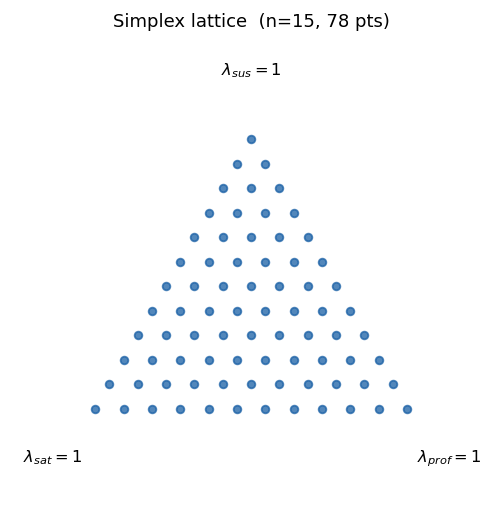

In [5]:
N_DIV = 15
grid_dicts = analyzer._generate_simplex_grid(n_points=N_DIV)

# Convert the dictionaries back to a NumPy array for matplotlib
ws = np.array([[w['lambda1'], w['lambda2'], w['lambda3']] for w in grid_dicts])

print(f'Grid resolution n={N_DIV}  →  {len(ws)} weight vectors')

# 2. Your Simplex Visualization (Unchanged)
px  = 0.5 * (2*ws[:,1] + ws[:,2])
py  = (np.sqrt(3)/2) * ws[:,2]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(px, py, s=18, c='#185FA5', alpha=0.75)

for label, xy in [('$\\lambda_{sat}=1$',(0,-0.07)),
                   ('$\\lambda_{prof}=1$',(1,-0.07)),
                   ('$\\lambda_{sus}=1$',(0.5, np.sqrt(3)/2+0.04))]:
    ax.annotate(label, xy=xy, ha='center', fontsize=9, fontweight='bold')

ax.set_xlim(-0.1,1.1); ax.set_ylim(-0.15,1.0)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Simplex lattice  (n={N_DIV}, {len(ws)} pts)', fontsize=10)
plt.tight_layout()
plt.show()

## Compute pareto fronts

In [25]:
# ═══ Main Sweeper (Linear, Chebyshev, and ε-Constraint) ═══════════════════════
# The ParetoFrontAnalyzer automatically generates the grids, runs the solvers, 
# normalizes the outputs, AND applies strict mathematical Pareto dominance filtering.

N_POINTS_SIMPLEX = 15  # For Linear and Chebyshev (generates Barycentric grid)
N_POINTS_EPSILON = 12  # For Epsilon (generates a 12x12 threshold grid)

print('--- Linear Scalarization ---')
front_linear = analyzer.compute_pareto_front(method='linear', n_points=N_POINTS_SIMPLEX)

print('--- Chebyshev Scalarization ---')
front_chebyshev = analyzer.compute_pareto_front(method='chebyshev', n_points=N_POINTS_SIMPLEX)

print('--- ε-Constraint ---')
front_epsilon = analyzer.compute_pareto_front(method='epsilon', n_points=N_POINTS_EPSILON)

total_solutions = len(front_linear) + len(front_chebyshev) + len(front_epsilon)
print('=' * 50)
print(f'Total STRICTLY Pareto-optimal solutions collected: {total_solutions}')
print('=' * 50)

--- Linear Scalarization ---
Sweeping 78 points using LINEAR scalarization...
IR Filter Stats: min=57, max=28430, mean=16113.0, std=7916.8
⚠️  WARNING: High variance in IR filtering across weights!
    Different weight regions have significantly different admissible job sets.
    This is EXPECTED and CORRECT behavior after the IR filter fix.
Generated 78 feasible solutions.
Filtered down to 78 strict Pareto-optimal points.

--- Chebyshev Scalarization ---
Sweeping 78 points using CHEBYSHEV scalarization...
IR Filter Stats: min=57, max=28430, mean=16113.0, std=7916.8
⚠️  WARNING: High variance in IR filtering across weights!
    Different weight regions have significantly different admissible job sets.
    This is EXPECTED and CORRECT behavior after the IR filter fix.
Generated 78 feasible solutions.
Filtered down to 78 strict Pareto-optimal points.

--- ε-Constraint ---
Sweeping 12x12 grid using EPSILON constraint...
Generated 144 feasible solutions.
Filtered down to 144 strict Pareto-

In [28]:
# Summary
print("\n" + "="*80)
print("PARETO FRONT GENERATION SUMMARY (n_points=15)")
print("="*80)
print(f"\nLinear Scalarization:     {len(front_linear):3d} Pareto-optimal points")
print(f"Epsilon-Constraint:       {len(front_epsilon):3d} Pareto-optimal points")
print(f"Chebyshev Scalarization:  {len(front_chebyshev):3d} Pareto-optimal points")


PARETO FRONT GENERATION SUMMARY (n_points=15)

Linear Scalarization:      78 Pareto-optimal points
Epsilon-Constraint:       144 Pareto-optimal points
Chebyshev Scalarization:   78 Pareto-optimal points


In [37]:
for i, sol in enumerate(front_linear, start=1):
    weights = sol.get("weights", {})
    vals = sol.get("normalized_objectives") or sol.get("normalized") or {}

    v_prof = vals.get("V_prof", float("nan"))
    v_sat  = vals.get("V_sat", float("nan"))
    v_sus  = vals.get("V_sus", float("nan"))

    print(f"solution {i:03d}")
    print(f"weights : {weights}")
    print(f"V_prof: {v_prof:.4f}, V_sat: {v_sat:.4f}, V_sus: {v_sus:.4f}")
    print()

solution 001
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.07142857142857142, 'lambda3': 0.8571428571428572}
V_prof: 0.0002, V_sat: 0.0002, V_sus: 1.0000

solution 002
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.14285714285714285, 'lambda3': 0.7857142857142858}
V_prof: 0.0033, V_sat: 0.0015, V_sus: 0.9993

solution 003
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.21428571428571427, 'lambda3': 0.7142857142857143}
V_prof: 0.5034, V_sat: 0.3030, V_sus: 0.8536

solution 004
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.2857142857142857, 'lambda3': 0.6428571428571429}
V_prof: 0.5410, V_sat: 0.3303, V_sus: 0.8371

solution 005
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.3571428571428571, 'lambda3': 0.5714285714285715}
V_prof: 0.5845, V_sat: 0.3513, V_sus: 0.8128

solution 006
weights : {'lambda1': 0.07142857142857142, 'lambda2': 0.42857142857142855, 'lambda3': 0.5}
V_prof: 0.8646, V_sat: 0.5775, V_sus: 0.5778

solution 007
weights : {'la

In [26]:
# Create compatibility aliases used by downstream cells
solutions_linear = front_linear
solutions_epsilon = front_epsilon
solutions_chebyshev = front_chebyshev

In [40]:
viz = ParetoFrontVisualizer(optimizer=optimizer, dpi=130)

## Generate Dominated Pool

In [41]:
dominated_pool = analyzer.compute_dominated_pool(n_random=800)

print(f'\n Generated {len(dominated_pool)} dominated solutions')
print('   These will appear as gray background points in plots')

Generating 800 random interior points...

 Generated 800 dominated solutions
   These will appear as gray background points in plots


## 2D Method comparison 


PLOTTING: linear 


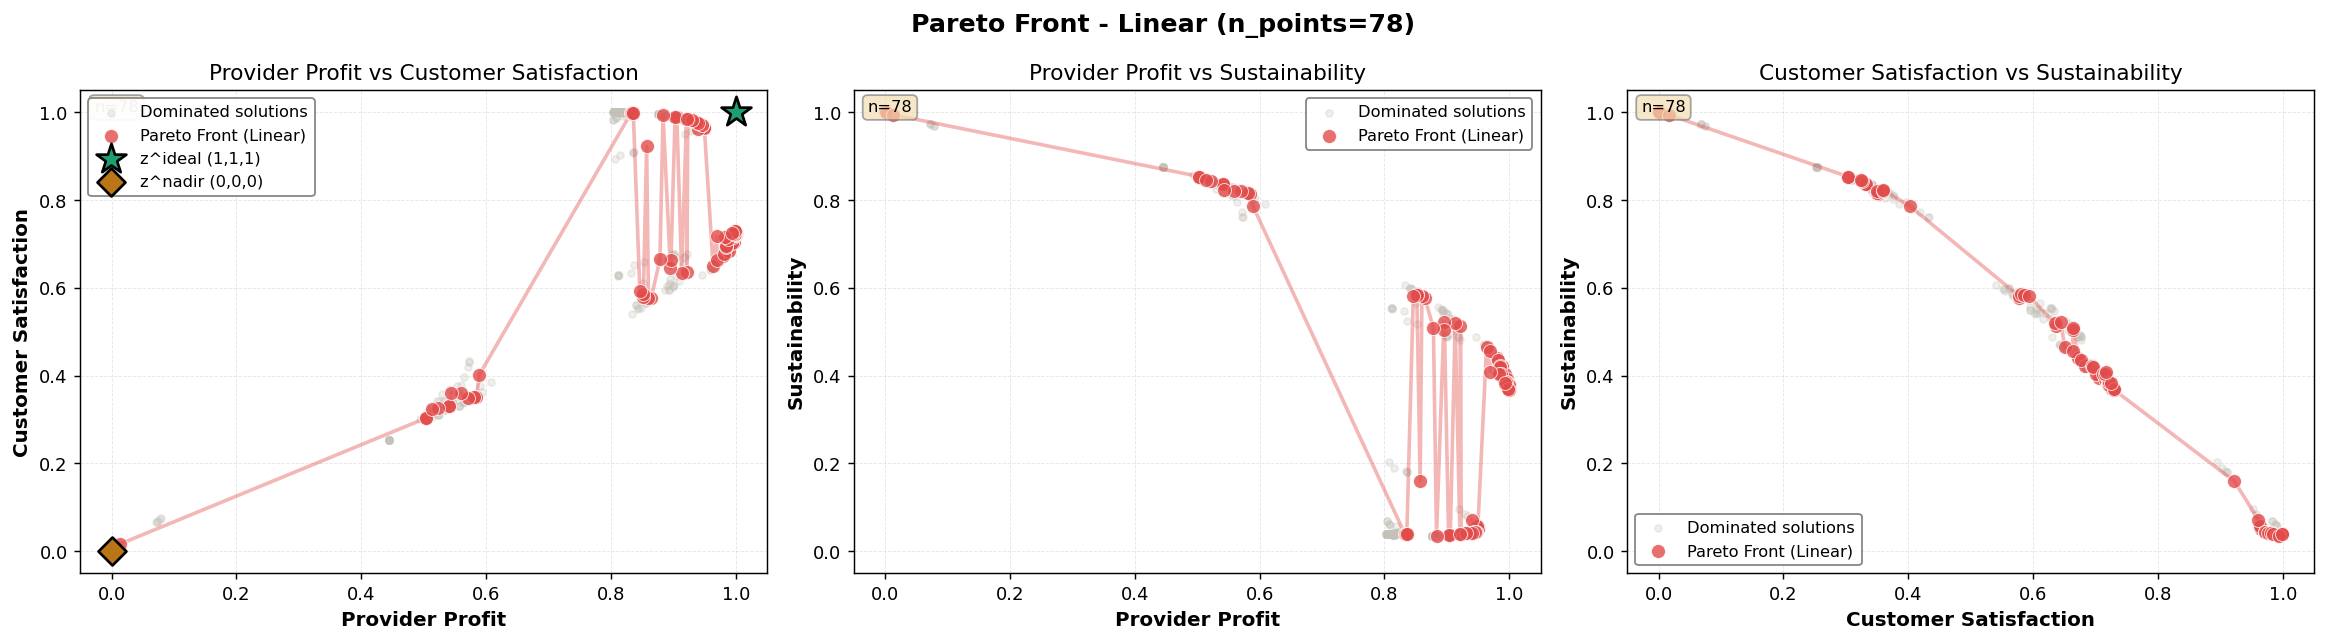


PLOTTING: epsilon 


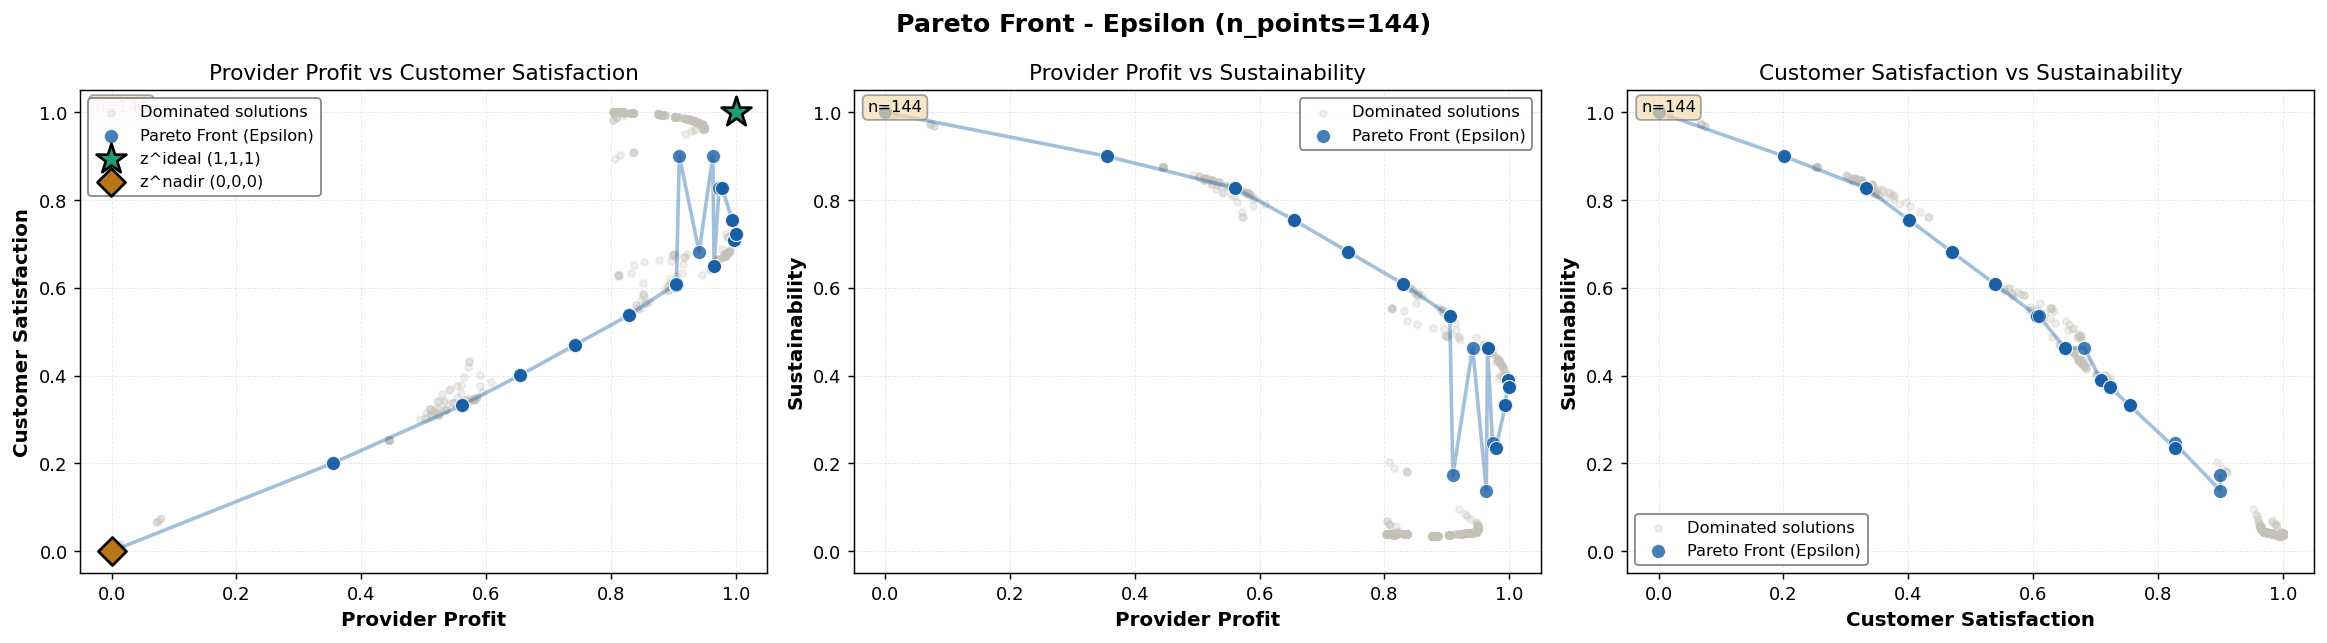


PLOTTING: chebyshev 


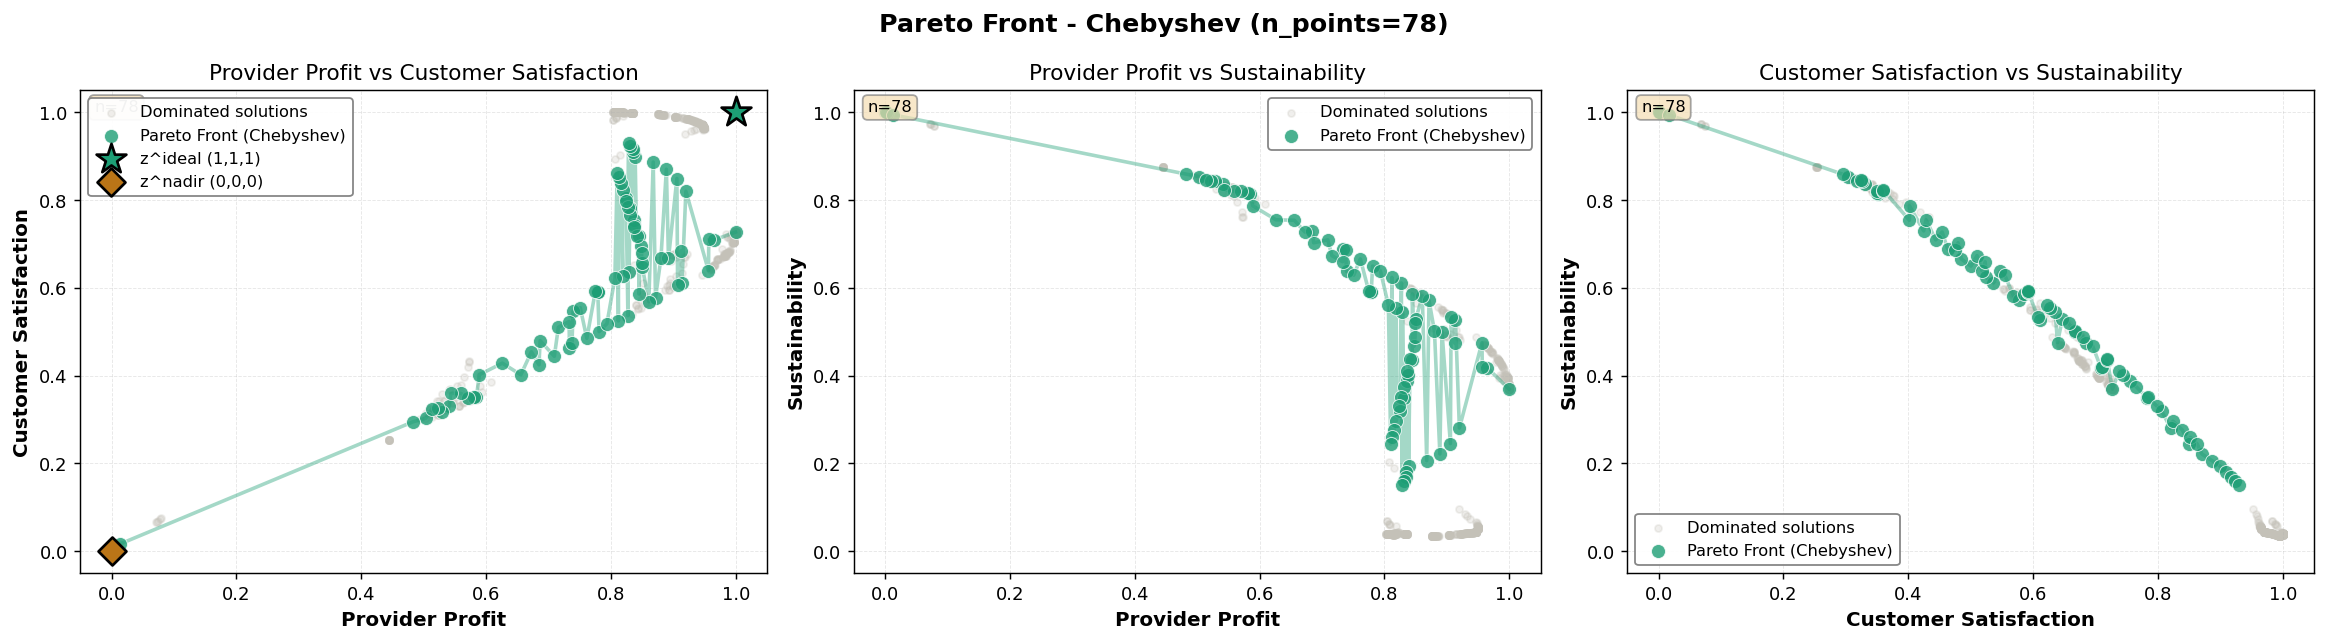

In [45]:
for method, sols in [('linear', solutions_linear),
                      ('epsilon', solutions_epsilon),
                      ('chebyshev', solutions_chebyshev)]:
    print("\n" + "="*80)
    print(f"PLOTTING: {method} ")
    print("="*80)
    fig = viz.plot_2d_pareto_with_dominated(
        sols, dominated_pool, 
        method.capitalize(), COLORS[method],
        f'Pareto Front - {method.capitalize()} (n_points={len(sols)})'
    )
    plt.show()

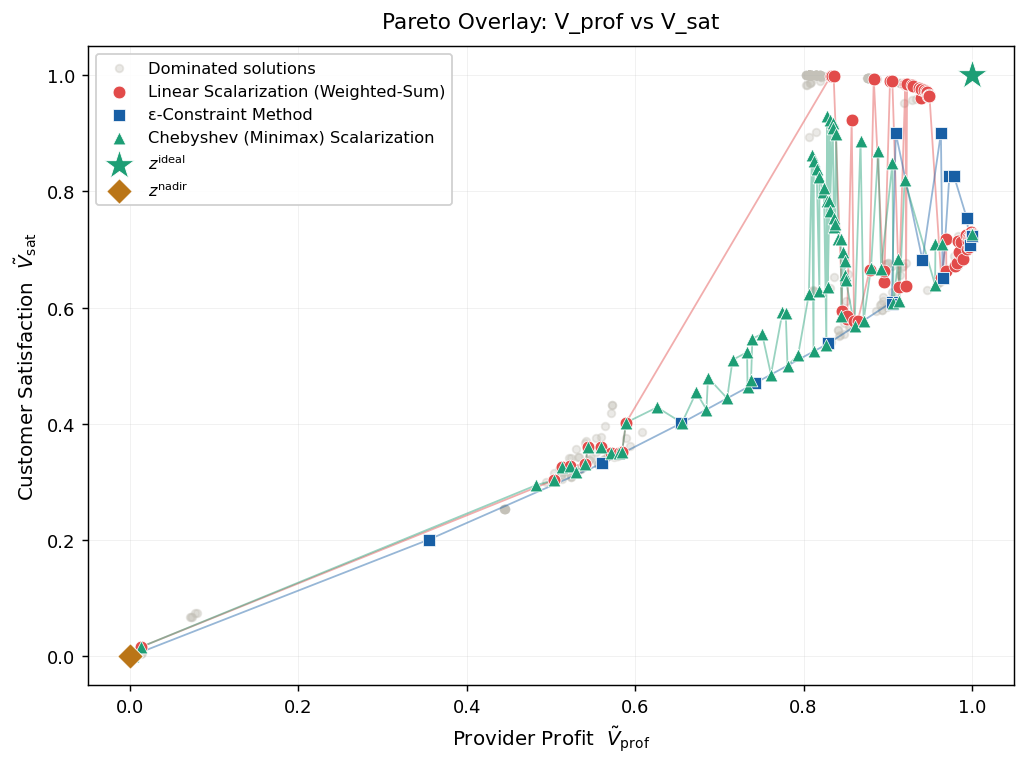

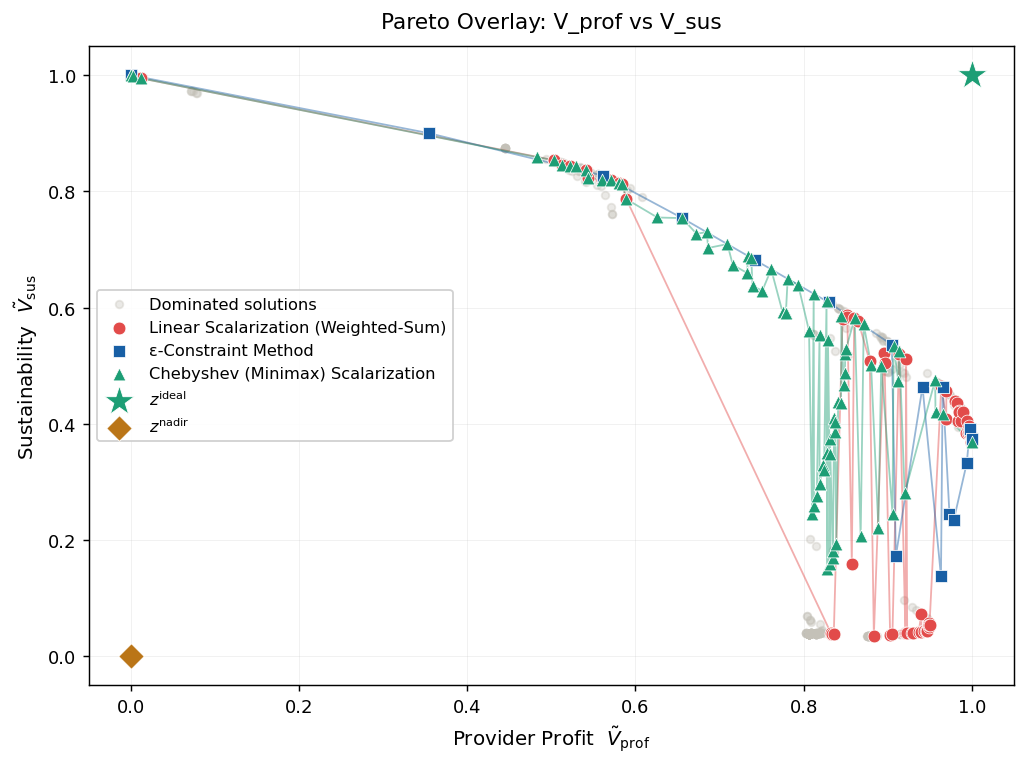

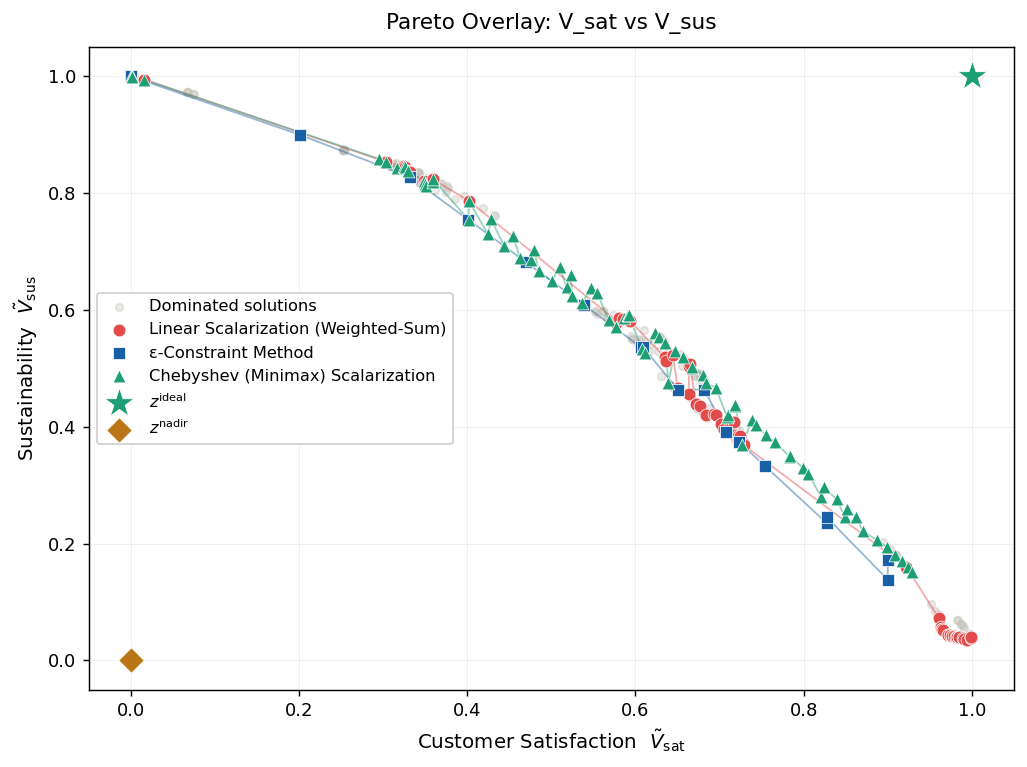

In [46]:
for obj_x, obj_y in [('V_prof','V_sat'), ('V_prof','V_sus'), ('V_sat','V_sus')]:
    viz.plot_overlay_2d(
        {'linear': solutions_linear, 'epsilon': solutions_epsilon, 'chebyshev': solutions_chebyshev},
        dominated_pool=dominated_pool,
        obj_x=obj_x, obj_y=obj_y,
        title=f'Pareto Overlay: {obj_x} vs {obj_y}',
    )
    plt.show()

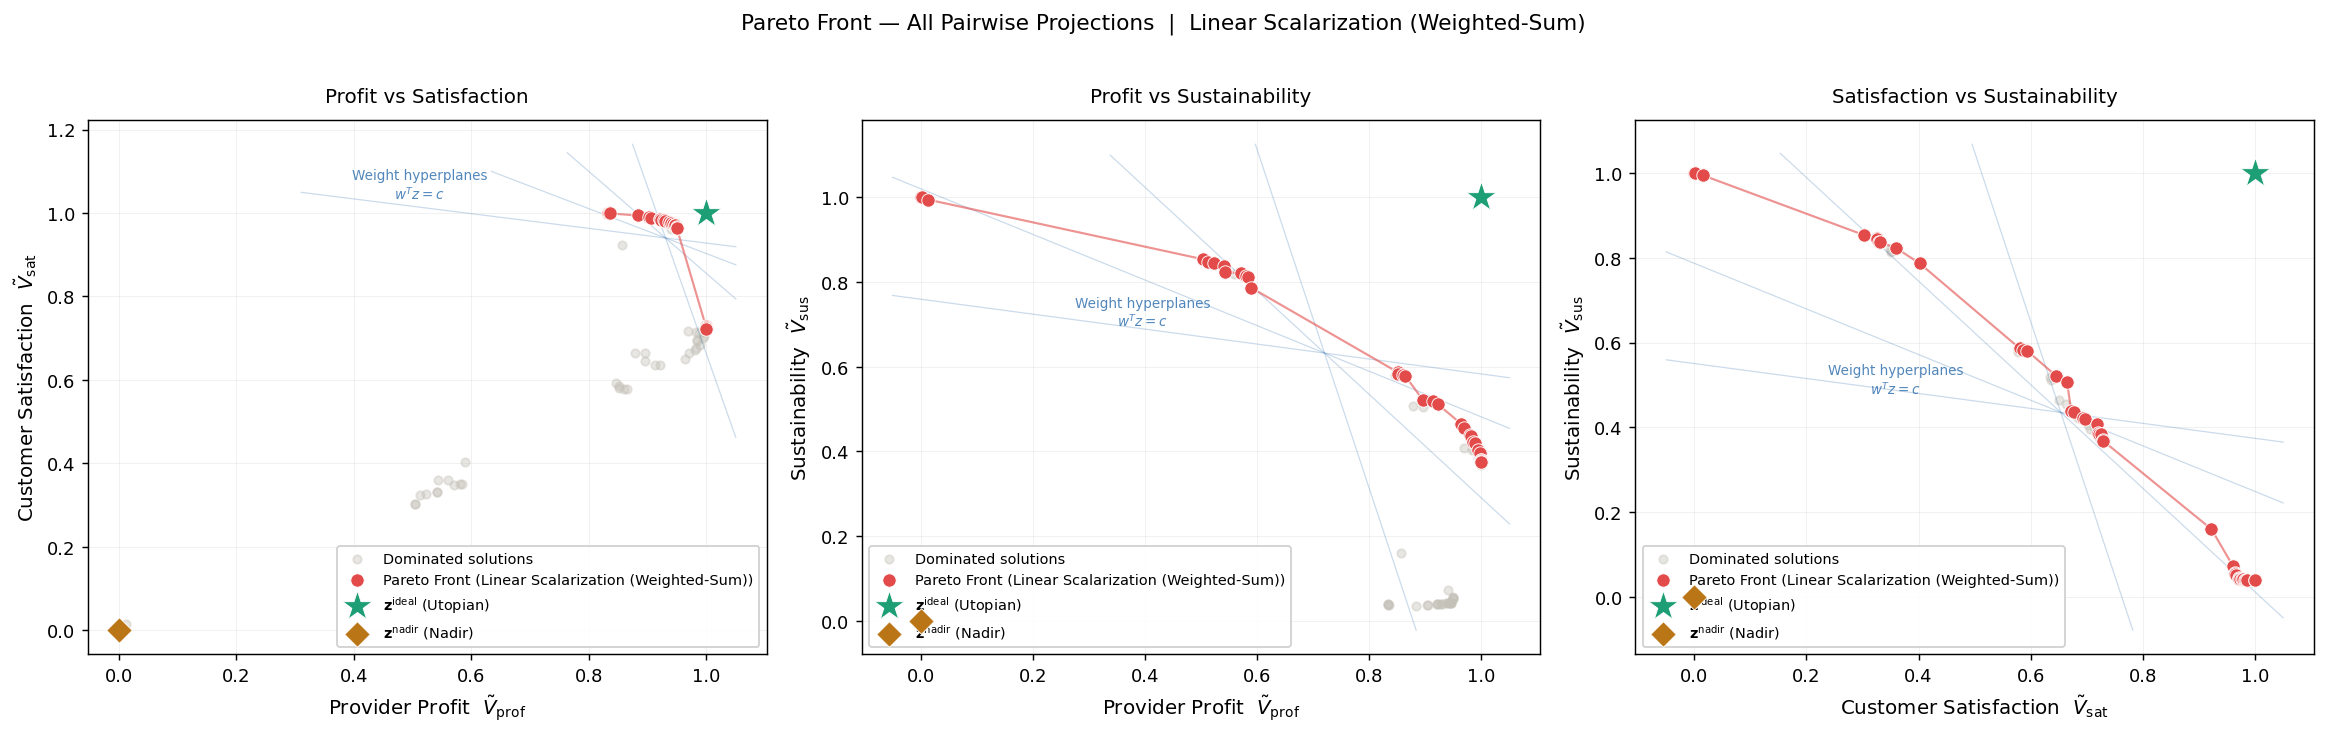

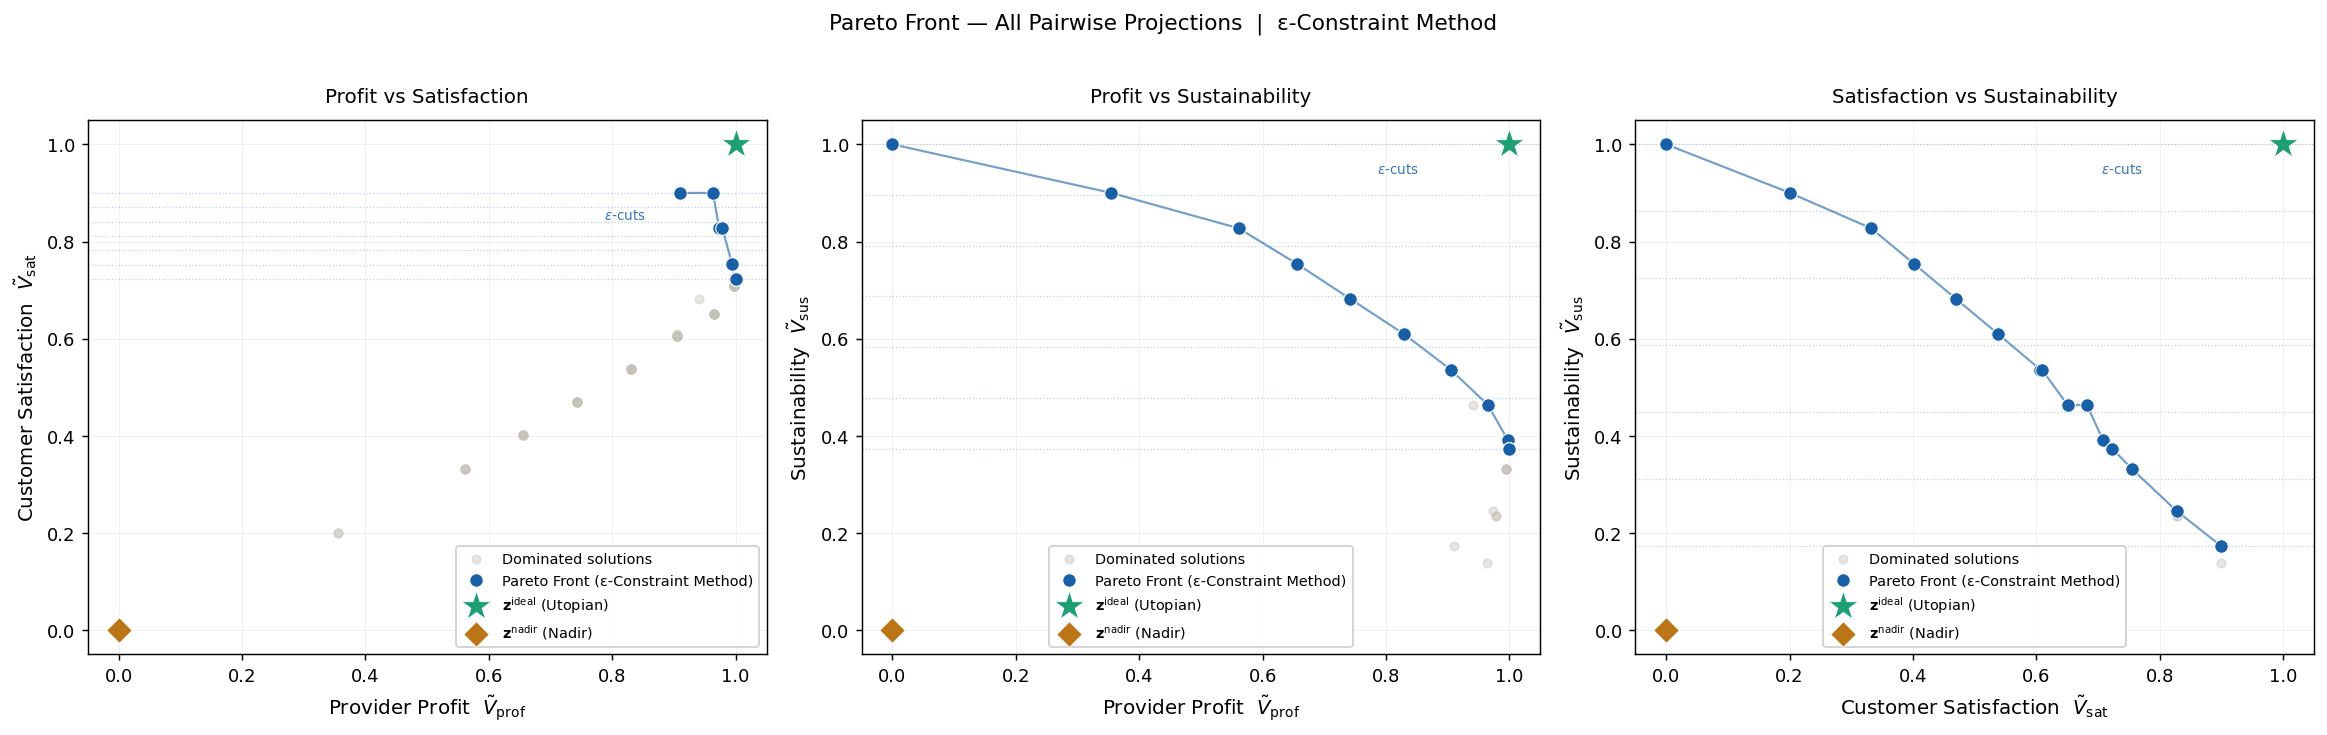

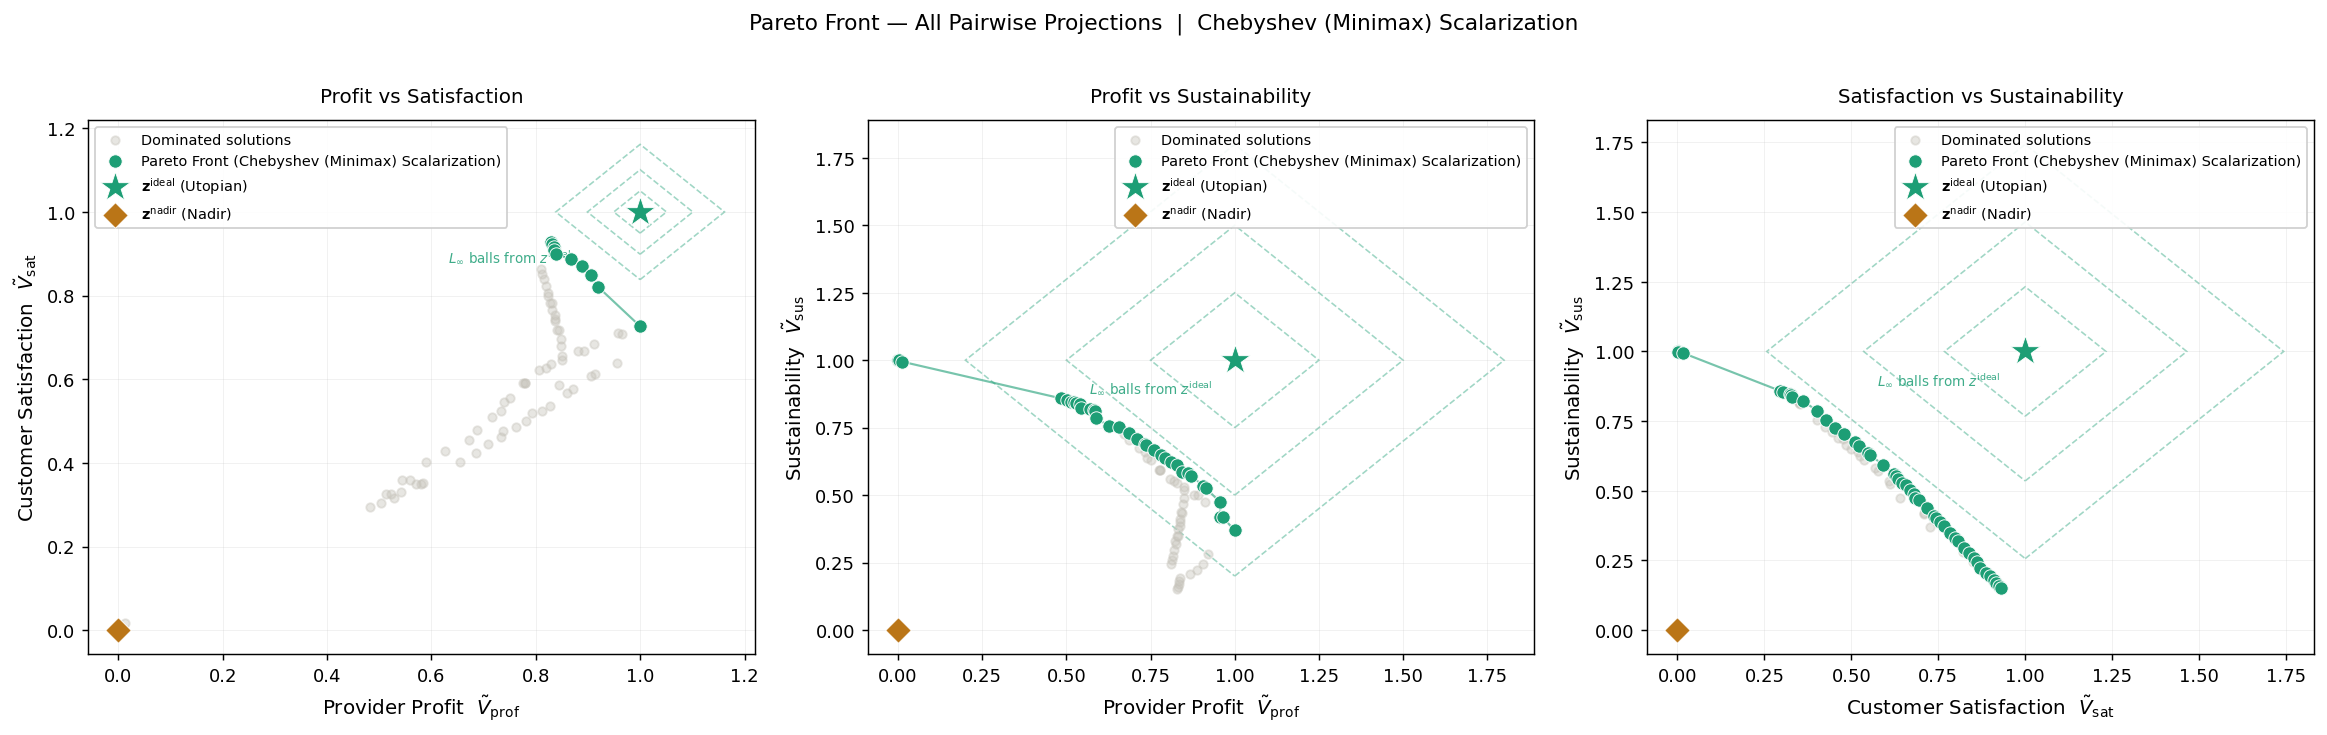

In [48]:
for method, sols in [('linear', solutions_linear),
                      ('epsilon', solutions_epsilon),
                      ('chebyshev', solutions_chebyshev)]:
    viz.plot_2d_all_projections(
        sols,
        dominated_pool=None,
        method_name=method,
        annotate_method_geometry=True,
    )
    plt.show()

## High Resolution Analysis (n_points=30)
Regenerate the LINEAR scalarization Pareto front with HIGHER resolution (n_points=30). If gaps persist, they are likely genuine non-convexities. If gaps disappear, they were sampling artifacts.

In [31]:
print('--- Linear Scalarization ---')
front_linear_30 = analyzer.compute_pareto_front(method='linear', n_points=30)

print("\n" + "="*80)
print("COMPARISON: n_points=15 vs n_points=30")
print("="*80)
print(f"\nLinear (n=15):  {len(front_linear):3d} Pareto-optimal points")
print(f"Linear (n=30):  {len(front_linear_30):3d} Pareto-optimal points")
print(f"Increase:       {len(front_linear_30) - len(front_linear):3d} additional points")
print(f"Growth factor:  {len(front_linear_30) / len(front_linear):.2f}x")

--- Linear Scalarization ---
Sweeping 378 points using LINEAR scalarization...
IR Filter Stats: min=3, max=29205, mean=16060.6, std=8226.3
⚠️  WARNING: High variance in IR filtering across weights!
    Different weight regions have significantly different admissible job sets.
    This is EXPECTED and CORRECT behavior after the IR filter fix.
Generated 378 feasible solutions.
Filtered down to 378 strict Pareto-optimal points.


COMPARISON: n_points=15 vs n_points=30

Linear (n=15):   78 Pareto-optimal points
Linear (n=30):  378 Pareto-optimal points
Increase:       300 additional points
Growth factor:  4.85x



PLOTTING: linear 


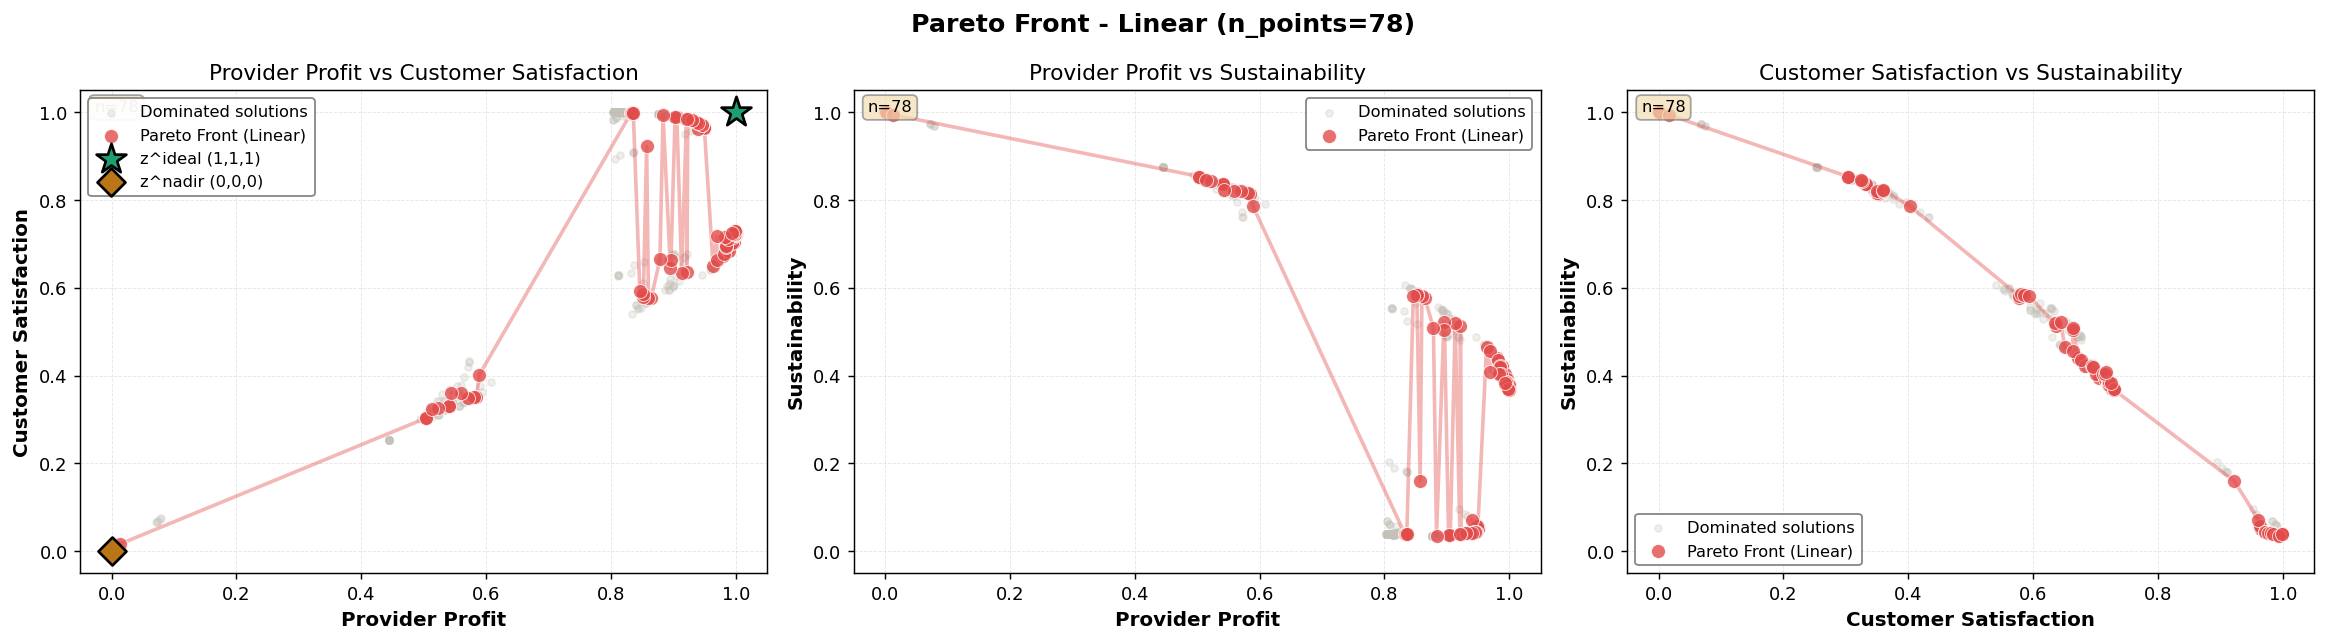


PLOTTING: linear 


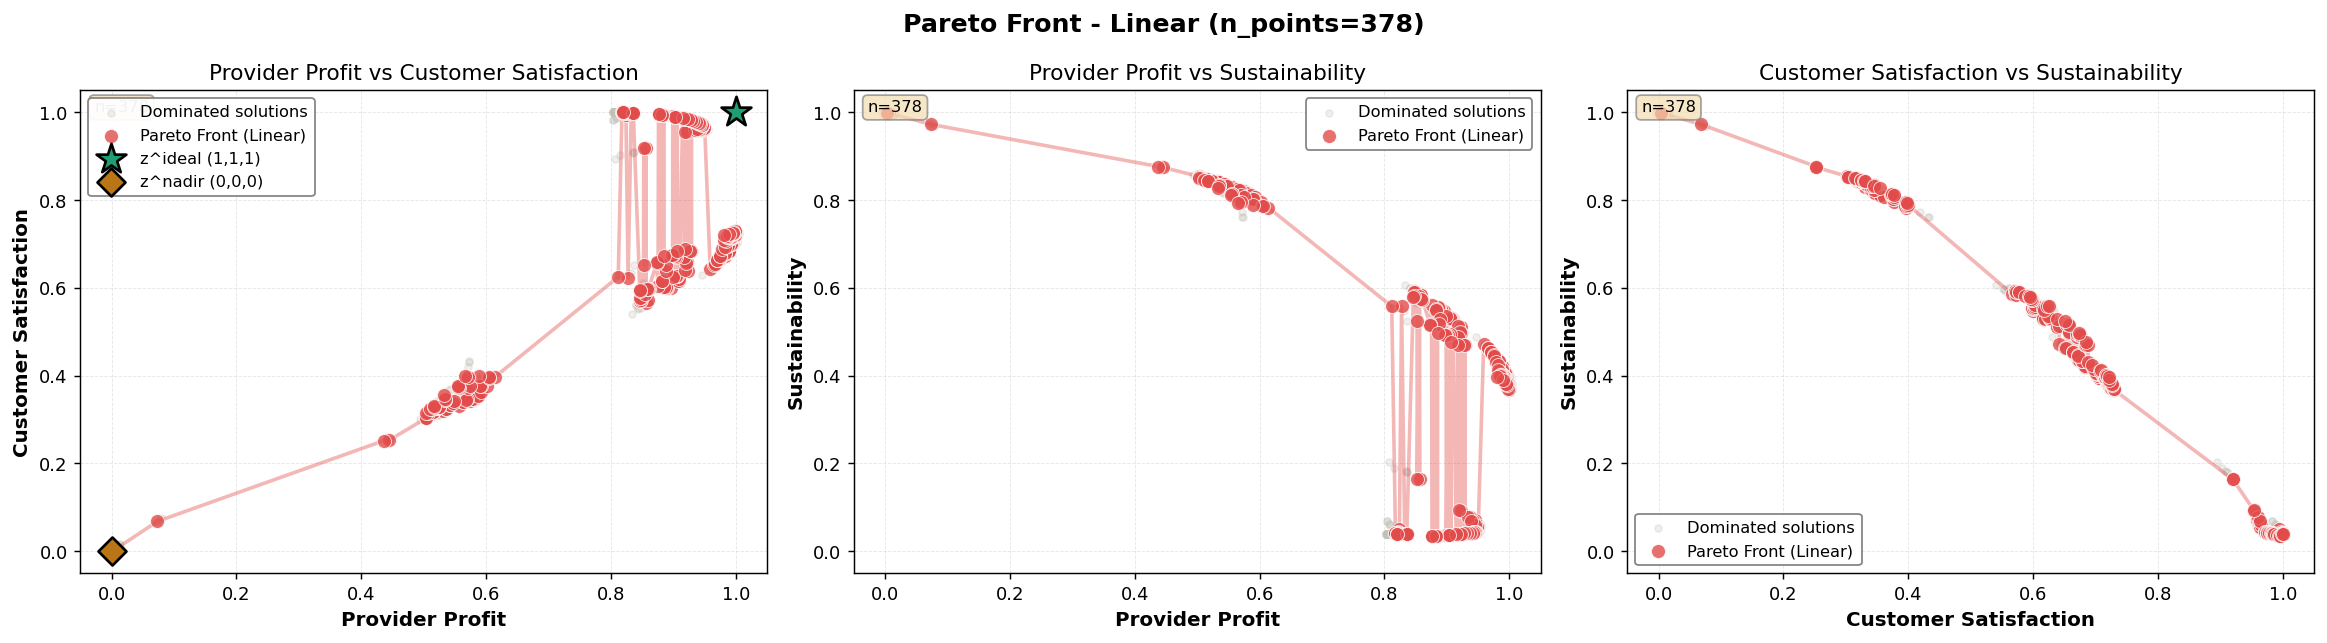

In [49]:
for method, sols in [('linear', front_linear), ('linear', front_linear_30)]:
    print("\n" + "="*80)
    print(f"PLOTTING: {method} ")
    print("="*80)
    fig = viz.plot_2d_pareto_with_dominated(
        sols, dominated_pool, 
        method.capitalize(), COLORS[method],
        f'Pareto Front - {method.capitalize()} (n_points={len(sols)})'
    )
    plt.show()

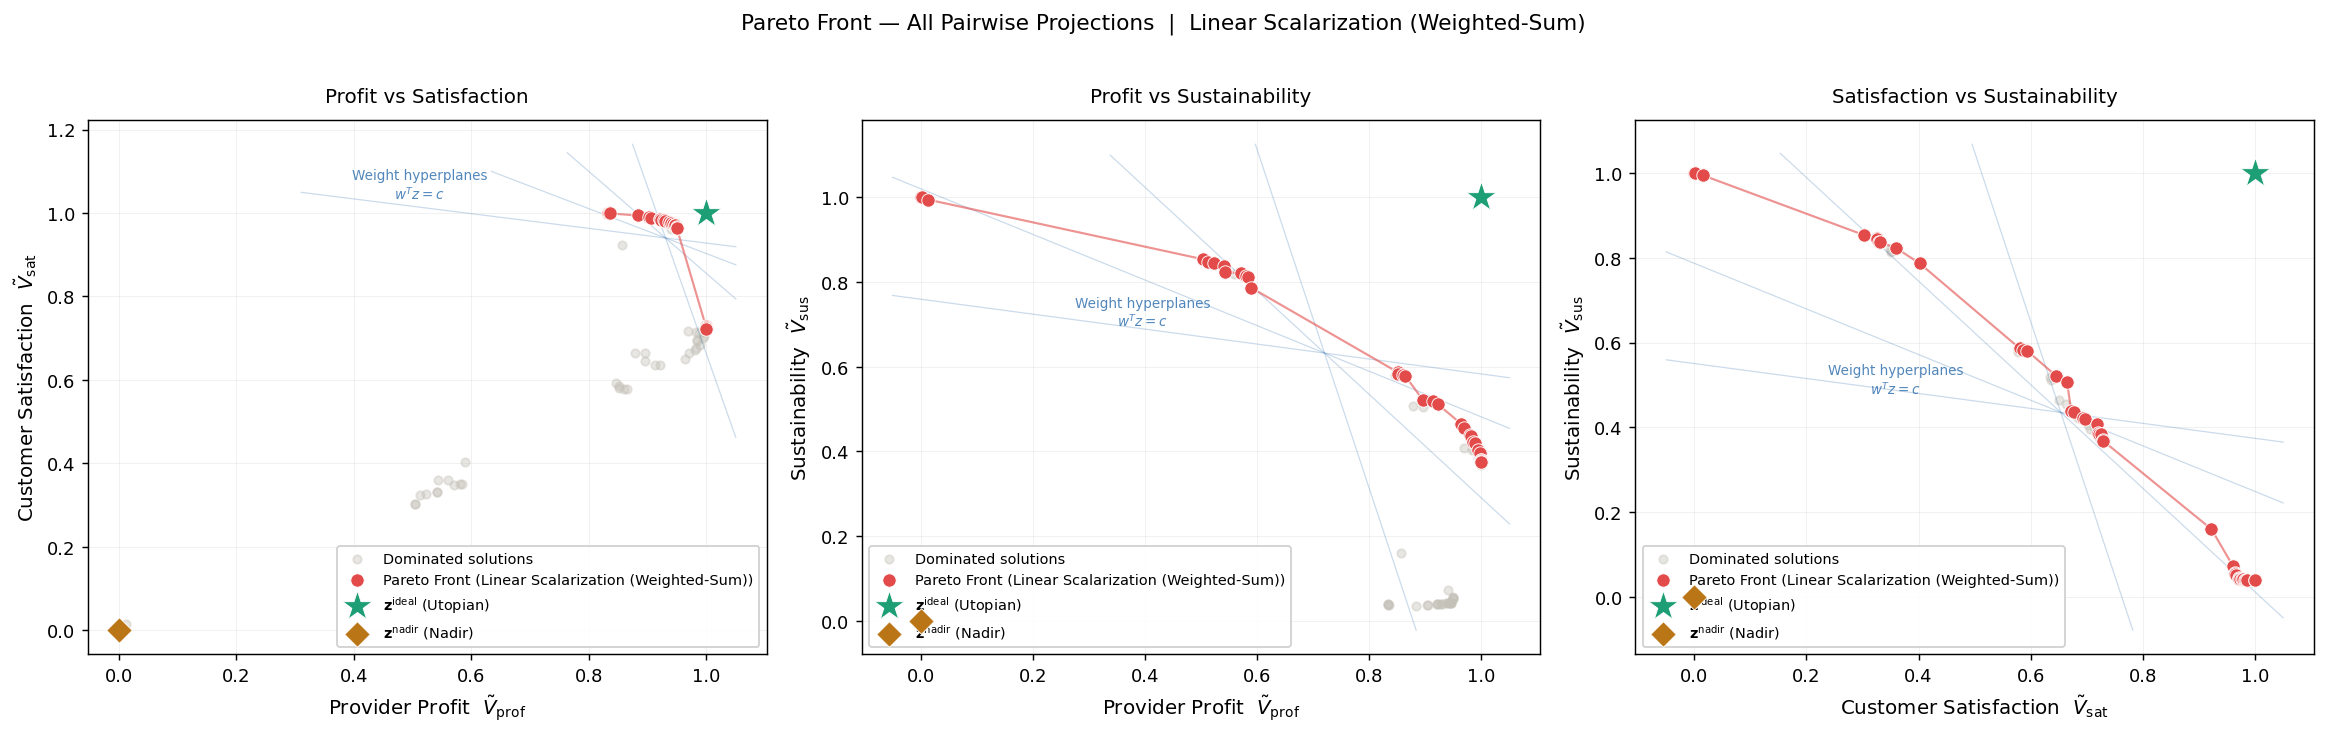

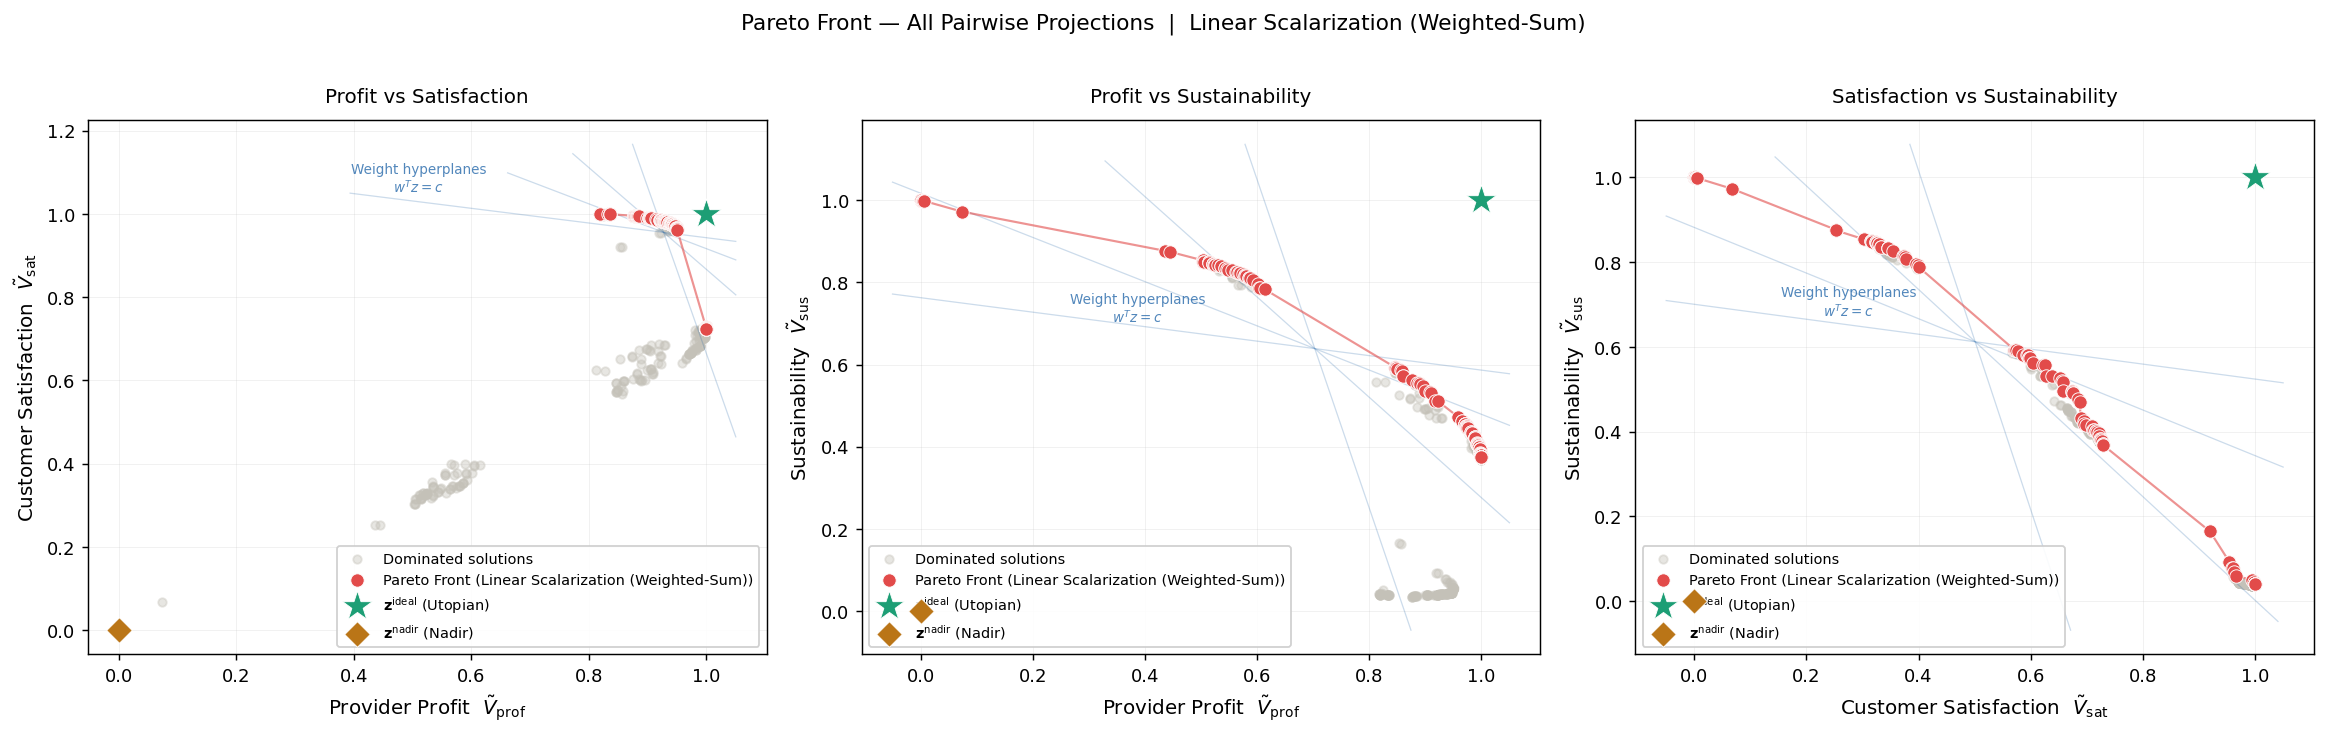

In [54]:
for method, sols in [('linear', front_linear), ('linear', front_linear_30)]:
    viz.plot_2d_all_projections(
        sols,
        dominated_pool=None,
        method_name=method,
        annotate_method_geometry=True,
    )
    plt.show()

## 3D Pareto surface

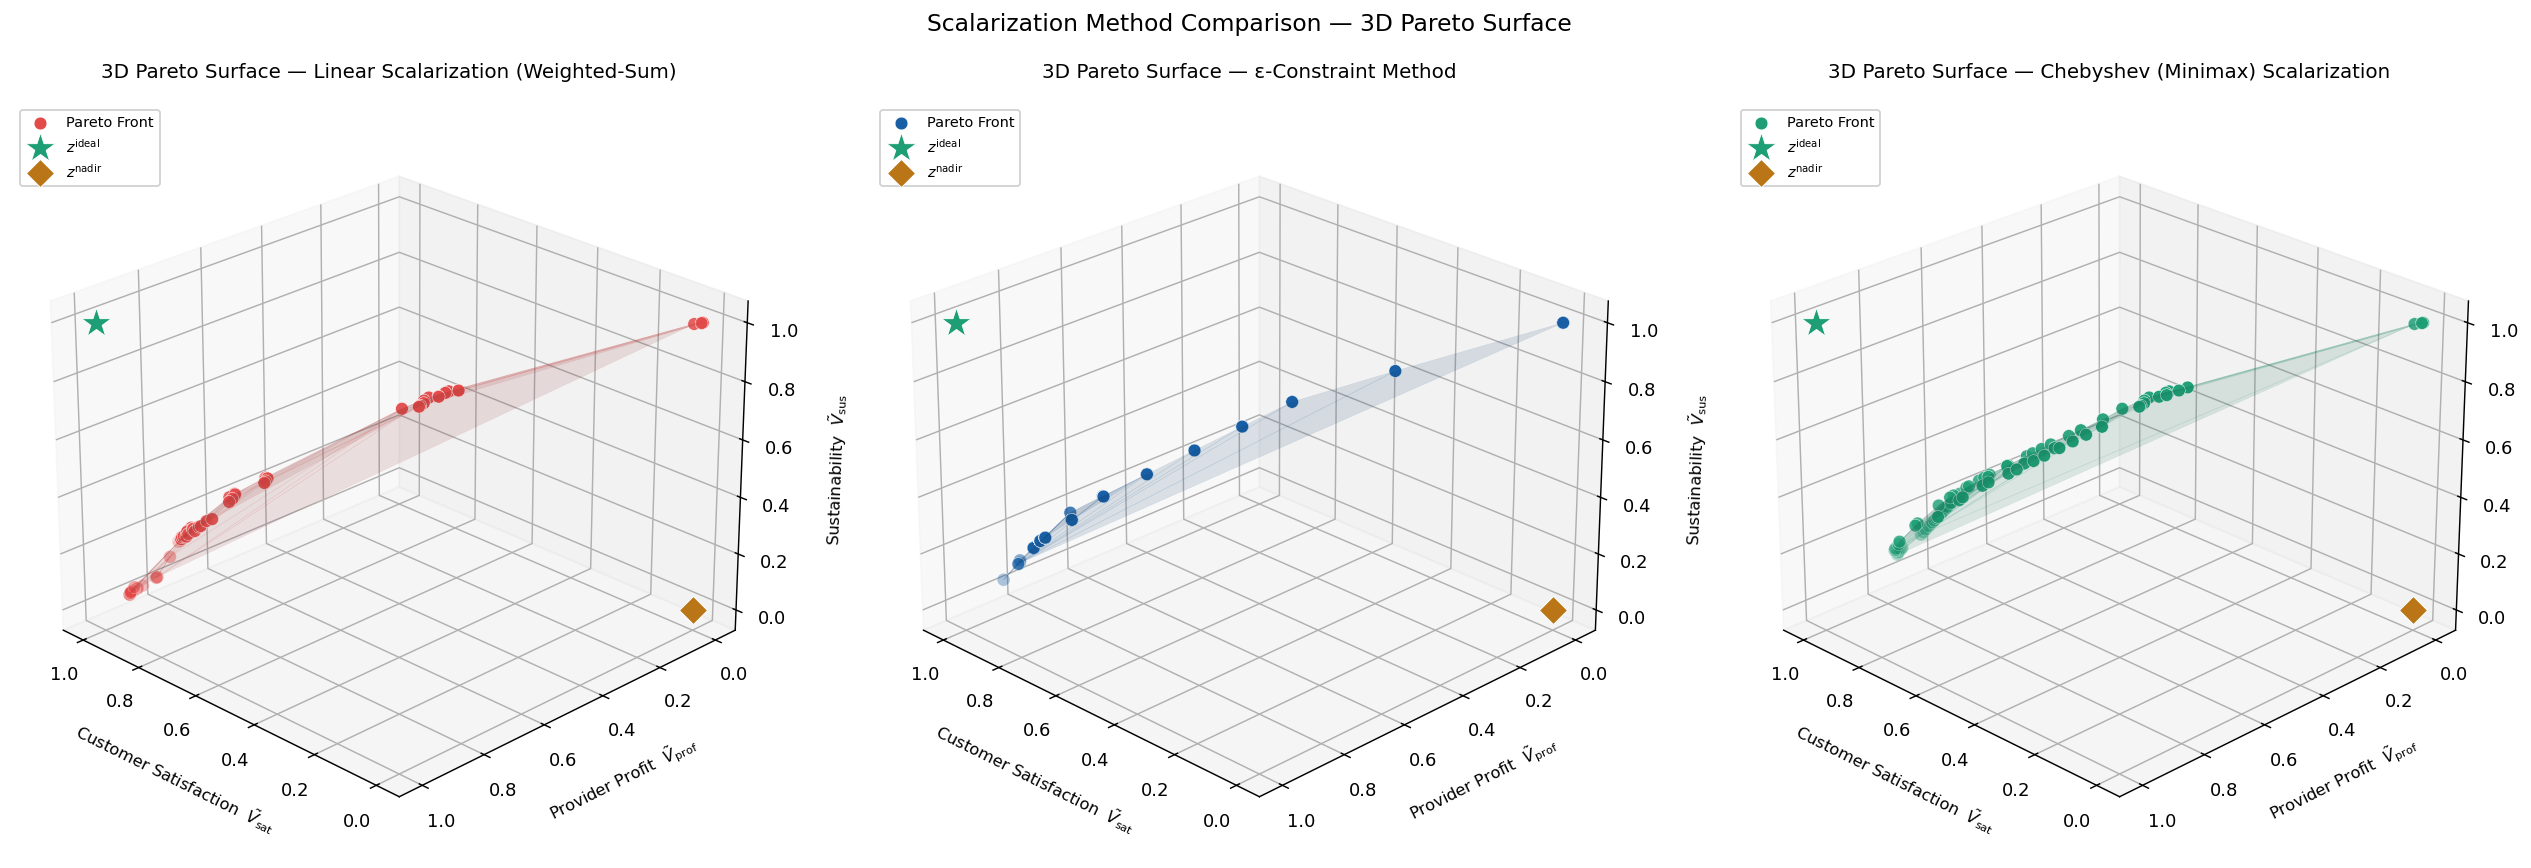

In [55]:
viz.plot_method_comparison_3d(
    solutions_linear, solutions_epsilon, solutions_chebyshev,
    dominated_pool=None,
    elev=25, azim=135,
)
plt.show()

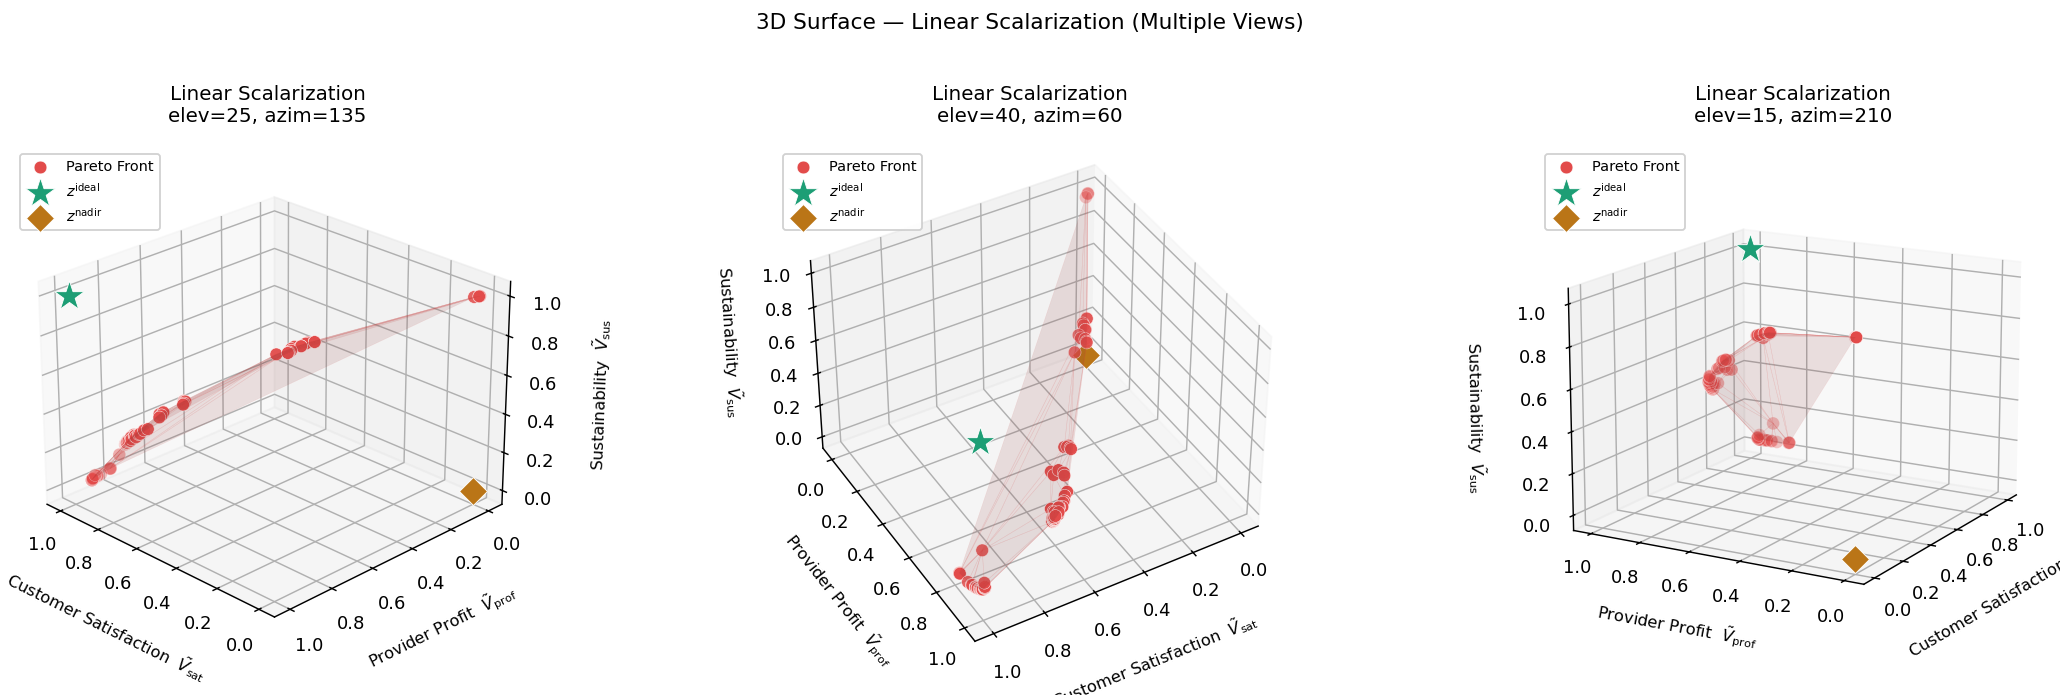

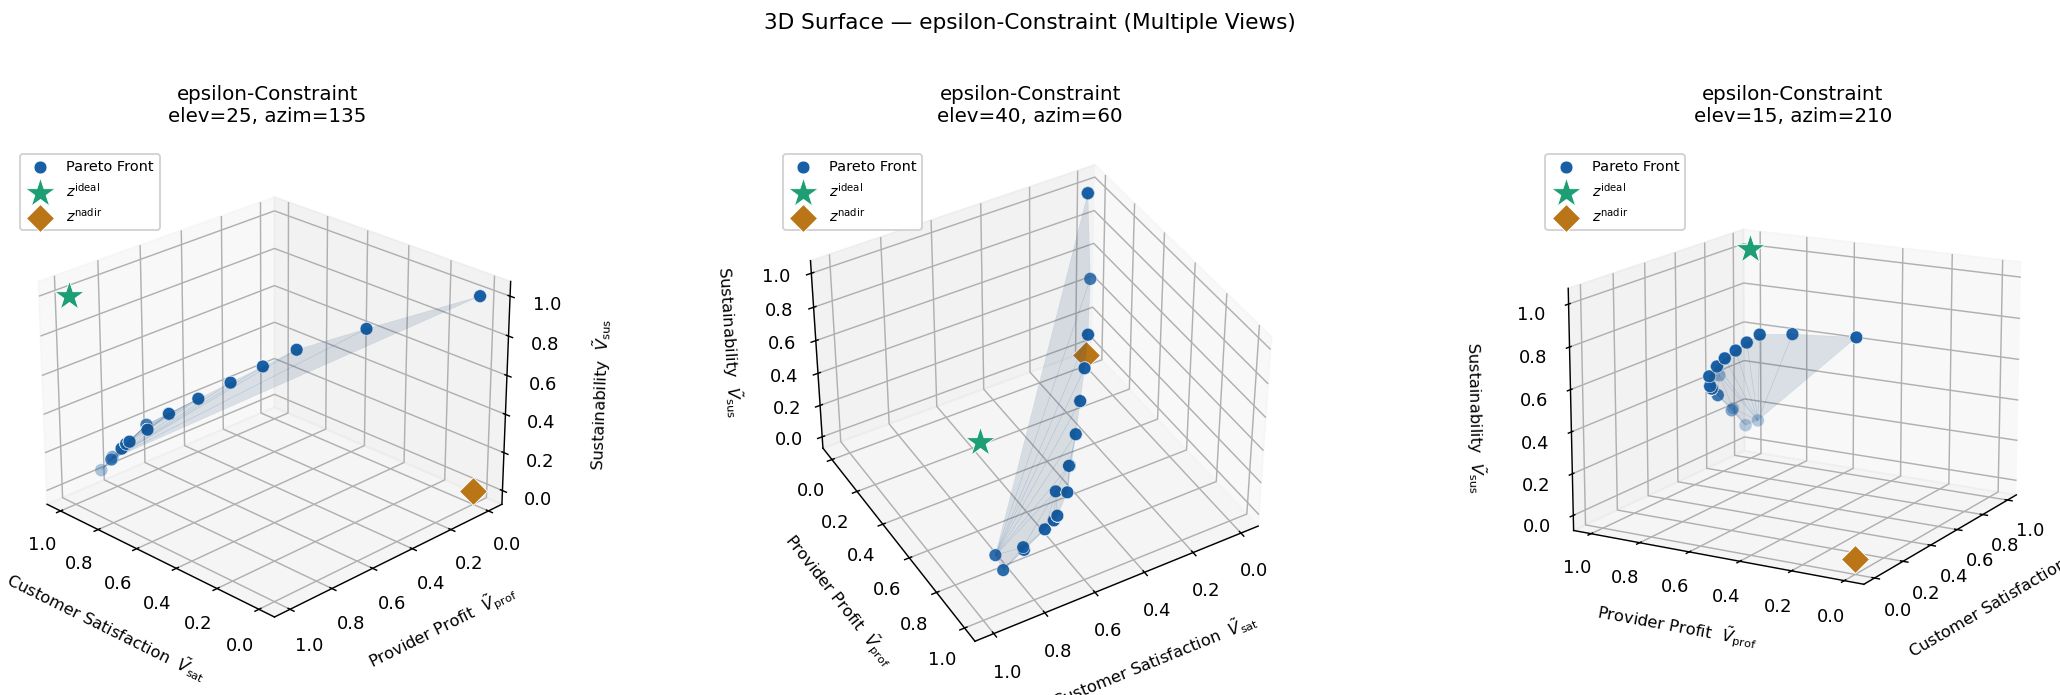

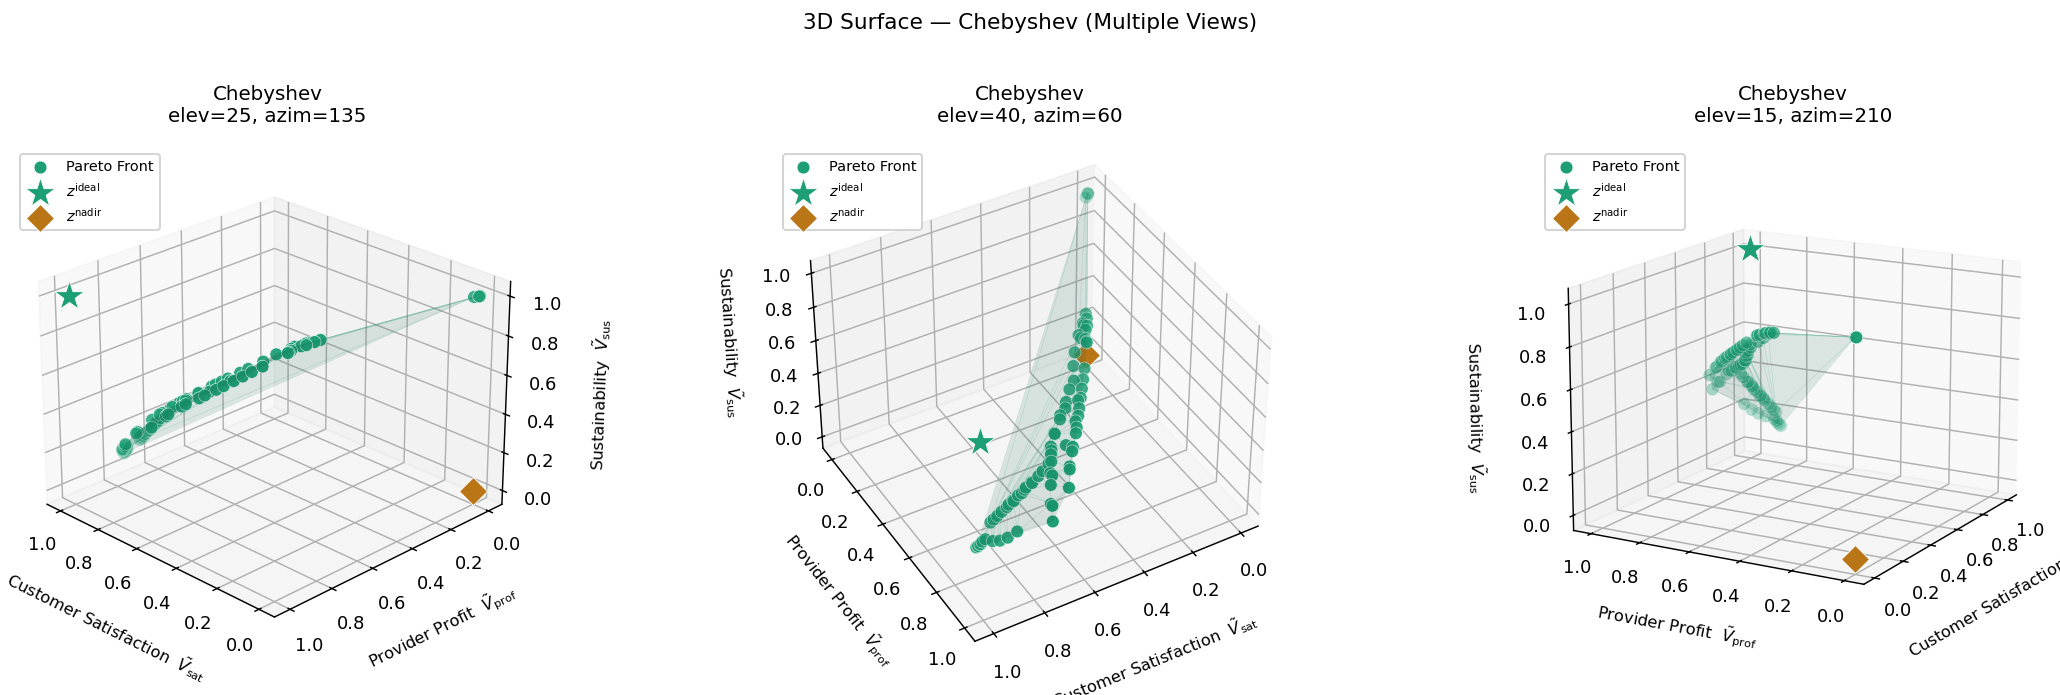

In [56]:
# Multiple camera angles per method
camera_angles = [(25, 135), (40, 60), (15, 210)]

for method, sols, label in [
    ('linear',    solutions_linear,    'Linear Scalarization'),
    ('epsilon',   solutions_epsilon,   'epsilon-Constraint'),
    ('chebyshev', solutions_chebyshev, 'Chebyshev'),
]:
    fig = plt.figure(figsize=(18, 5))
    for idx, (elev, azim) in enumerate(camera_angles):
        ax = fig.add_subplot(1, 3, idx+1, projection='3d')
        viz.plot_3d_front(
            sols,
            dominated_pool=None,
            method_name=method,
            elev=elev, azim=azim,
            show_surface=True,
            title=f'{label}\nelev={elev}, azim={azim}',
            ax=ax,
        )
    fig.suptitle(f'3D Surface — {label} (Multiple Views)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

<a id='section6'></a>
## Gap analysis with binary search
This test determines whether gaps in the Pareto front are:
1. **ARTIFACTS**: Due to insufficient sampling resolution (fixable)
2. **GENUINE**: Due to mathematical non-convexity (method limitation)

### Algorithm:

For each gap between points A and B:
1. Compute midpoint weights: $\lambda_{mid} = (\lambda_A + \lambda_B) / 2$
2. Solve LP with $\lambda_{mid}$
3. Check if solution is:
   - **NEW** intermediate point → Gap is ARTIFACT (front is convex)
   - **SNAPS** to A or B → Continue bisecting
4. Repeat until:
   - Intermediate point found → **CONVEX**
   - Weights converge without intermediate point → **NON-CONVEX**

### Interpretation:

- If **ALL gaps are filled** → Pareto front is CONVEX
  - Linear Scalarization is adequate
  - Increase n_points for smoother visualization

- If **gaps PERSIST** → Pareto front has NON-CONVEX regions
  - Linear Scalarization has fundamental limitations
  - Must use Chebyshev or Epsilon-Constraint for complete coverage

In [57]:
# Run gap analysis
results = gap_analysis.run_complete_gap_analysis(
    pareto_front=front_linear,
    analyzer=analyzer,
    gap_threshold=0.15,
    max_iterations=20,
    tolerance=1e-6
)


STEP 1: IDENTIFYING GAPS IN PARETO FRONT

GAP DETECTION: Identified 13 potential gaps with distance > 0.15
Gap #1: Distance = 0.5856
  Point A: V_sat=0.016, V_prof=0.013, V_sus=0.994
  Point B: V_sat=0.303, V_prof=0.503, V_sus=0.854
Gap #2: Distance = 0.9871
  Point A: V_sat=0.402, V_prof=0.589, V_sus=0.787
  Point B: V_sat=0.999, V_prof=0.833, V_sus=0.039
Gap #3: Distance = 0.6774
  Point A: V_sat=0.999, V_prof=0.836, V_sus=0.038
  Point B: V_sat=0.593, V_prof=0.846, V_sus=0.581
Gap #4: Distance = 0.5414
  Point A: V_sat=0.586, V_prof=0.852, V_sus=0.584
  Point B: V_sat=0.922, V_prof=0.857, V_sus=0.160
Gap #5: Distance = 0.5448
  Point A: V_sat=0.922, V_prof=0.857, V_sus=0.160
  Point B: V_sat=0.577, V_prof=0.860, V_sus=0.582
Gap #6: Distance = 0.5760
  Point A: V_sat=0.665, V_prof=0.878, V_sus=0.508
  Point B: V_sat=0.994, V_prof=0.883, V_sus=0.035
Gap #7: Distance = 0.5994
  Point A: V_sat=0.994, V_prof=0.883, V_sus=0.035
  Point B: V_sat=0.645, V_prof=0.895, V_sus=0.522
Gap #8: Di

## Convexity Diagnostic

1. Convex hull membership test
2. Gap detection
3. Chord test: $\lambda A + (1-\lambda)B$

---

Simple methods like Linear Scalarization completely fail to find solutions in concave (caved-in) regions of a Pareto front, whereas methods like Chebyshev or Epsilon-Constraint can find them.

**1. Gap detection**
Before checking for curves, the code checks for holes. A mathematically "convex" front implies a continuous curve. If the Pareto front is fractured into disconnected islands, it is non-convex by definition. The code looks at the distance between adjacent points along the x-axis. It calculates the mean ($\mu$) and standard deviation ($\sigma$) of these distances. It sets a threshold of $\mu + 3\sigma$. If any gap between two points is larger than this statistical threshold, it flags the front as having a "gap" (disconnected).

**2. Convex Hull test**
Imagine stretching a rubber band around all the points in your Pareto front. The shape formed by that tight rubber band is the Convex Hull. If the Pareto front is purely convex, every single point on the front will touch that rubber band. If the front has a non-convex (concave/caved-in) region, some points will fall inside the rubber band rather than forming its boundary. The code checks this via: len(hull.vertices) == len(pareto_pts_2d). If true, the front is convex.

**3. The Chord test**
If a curve is convex, drawing a straight line segment (a chord) between any two points on the curve will result in the entire curve lying on or below that line (if maximizing) or on or above that line (if minimizing). The code selects two points, $A$ (20% down the front) and $B$ (80% down the front). It calculates points along a straight line connecting them using the convex combination formula: $\lambda A + (1-\lambda)B$, where $\lambda$ ranges from $0$ to $1$.

Based on the tests above, the code combines the results to spit out one of three labels:

- **CONVEX (connected)**: Every point touches the convex hull, and there are no statistical gaps.
- **NON-CONVEX (disconnected front)**: The algorithm detected a massive gap in the points.
- **NON-CONVEX (concave region, connected)**: There are no massive gaps, but some points fell inside the convex hull, meaning the front "caves in" somewhere.



CONVEXITY DIAGNOSTIC RESULTS

  Linear Scalarization


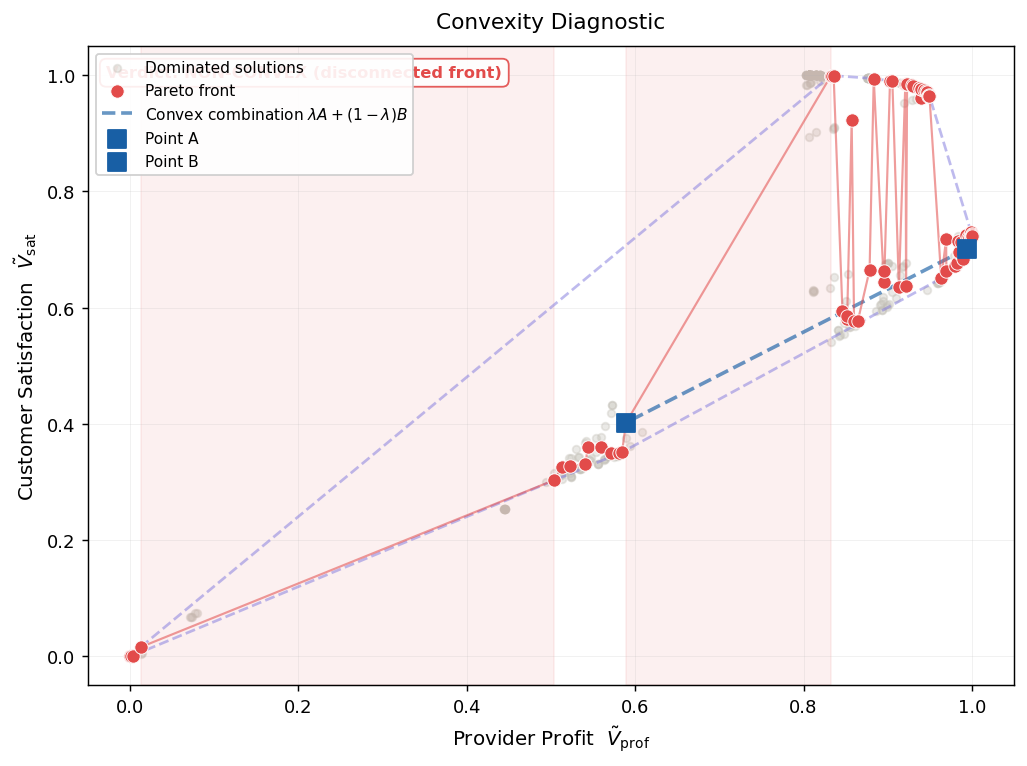

    Profit vs Satisfaction                 → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=2  all_on_hull=False


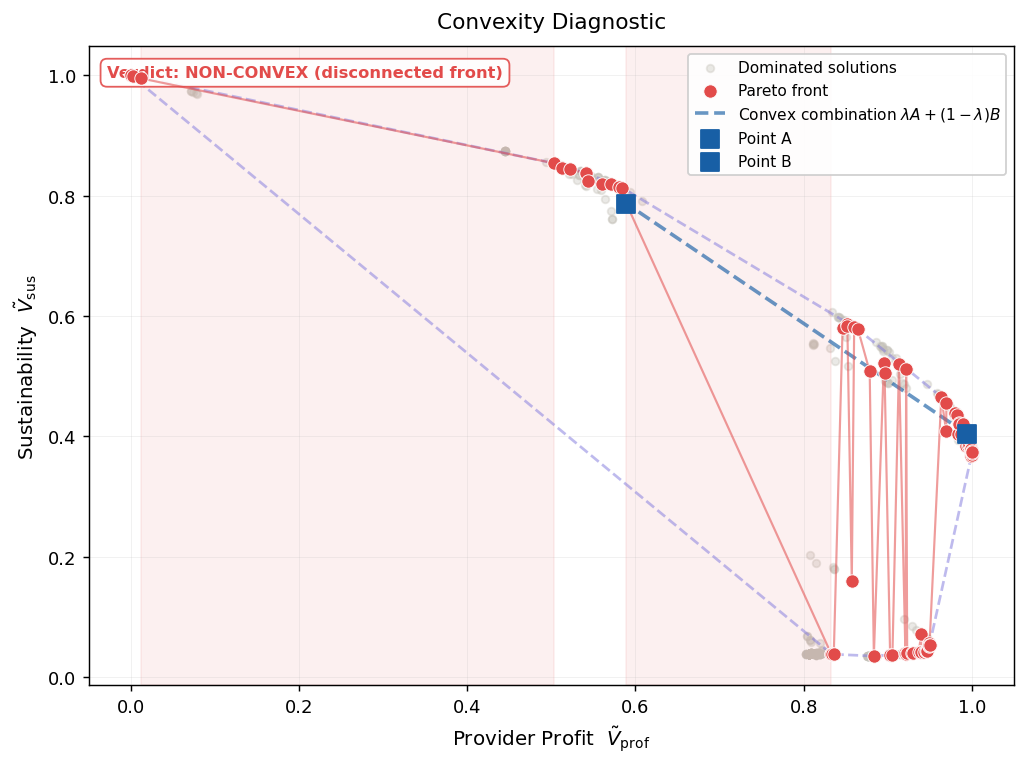

    Profit vs Sustainability               → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=2  all_on_hull=False


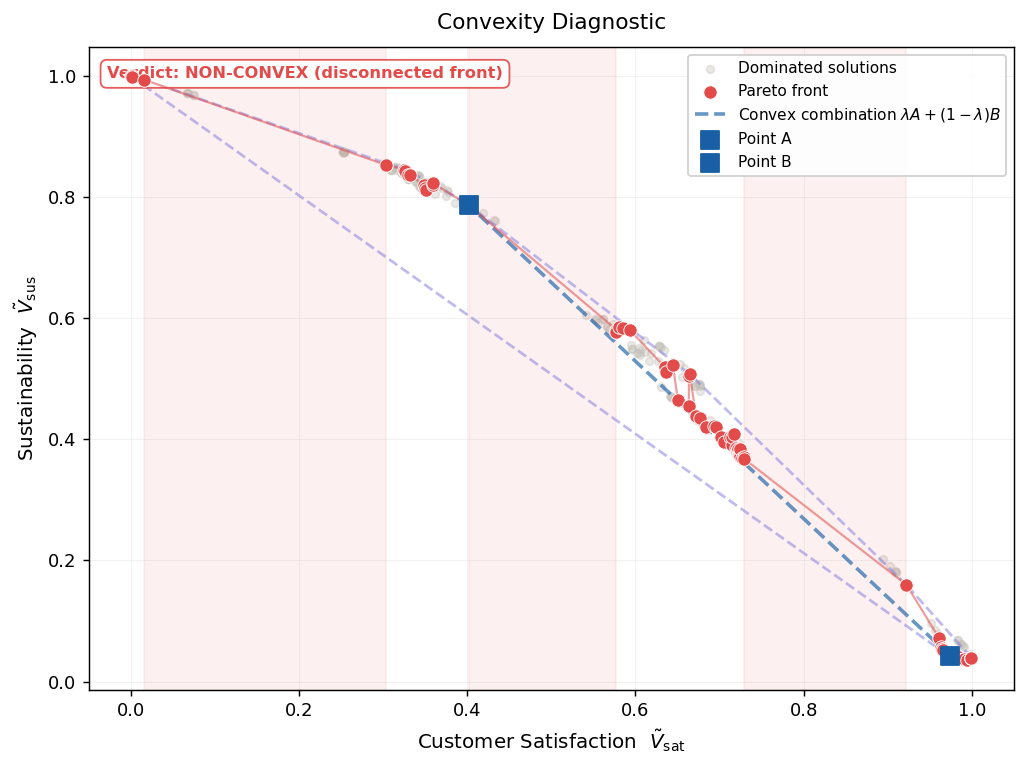

    Satisfaction vs Sustainability         → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=3  all_on_hull=False

  epsilon-Constraint


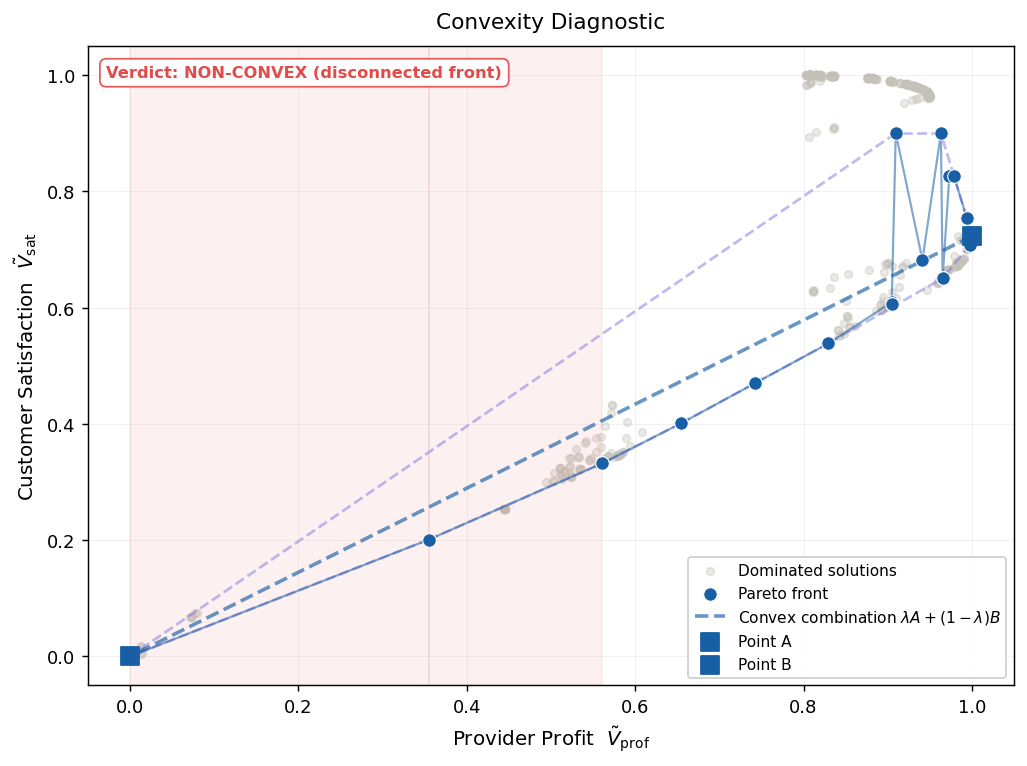

    Profit vs Satisfaction                 → NON-CONVEX (disconnected front)
       Pareto pts=144  gaps=2  all_on_hull=False


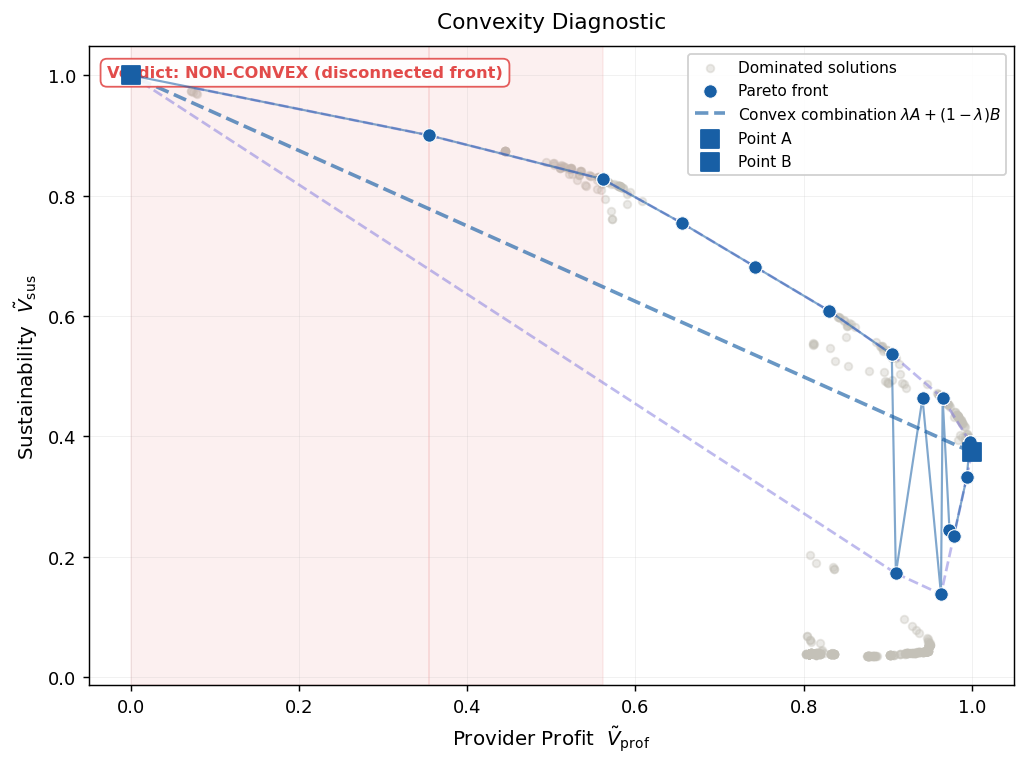

    Profit vs Sustainability               → NON-CONVEX (disconnected front)
       Pareto pts=144  gaps=2  all_on_hull=False


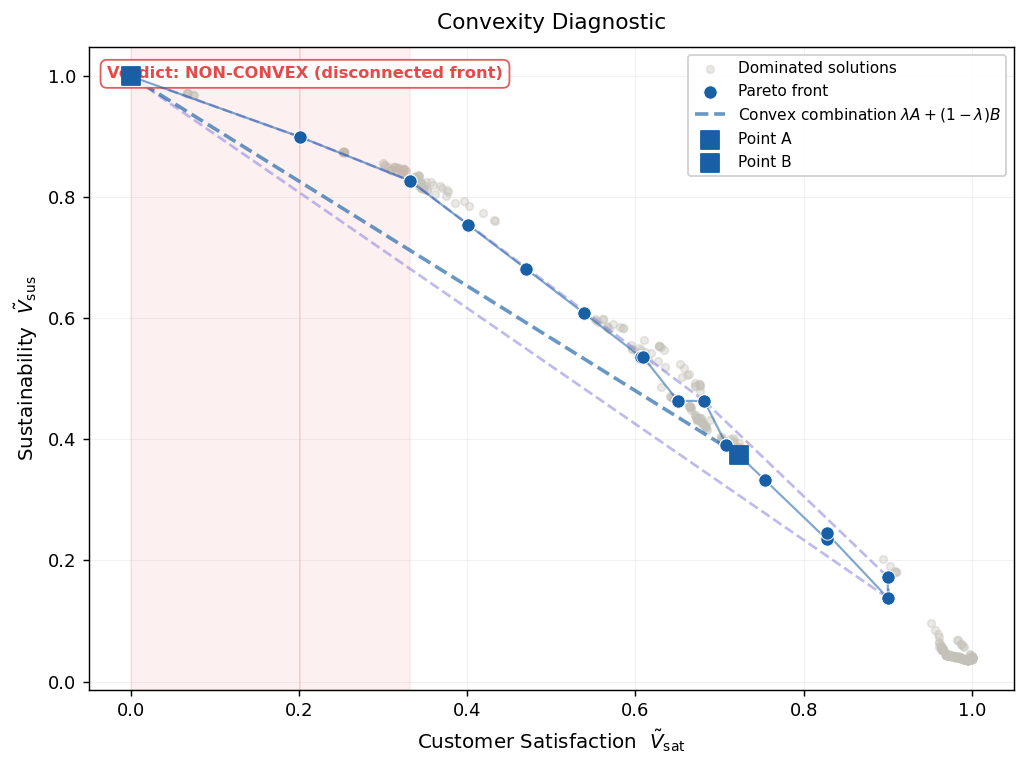

    Satisfaction vs Sustainability         → NON-CONVEX (disconnected front)
       Pareto pts=144  gaps=2  all_on_hull=False

  Chebyshev


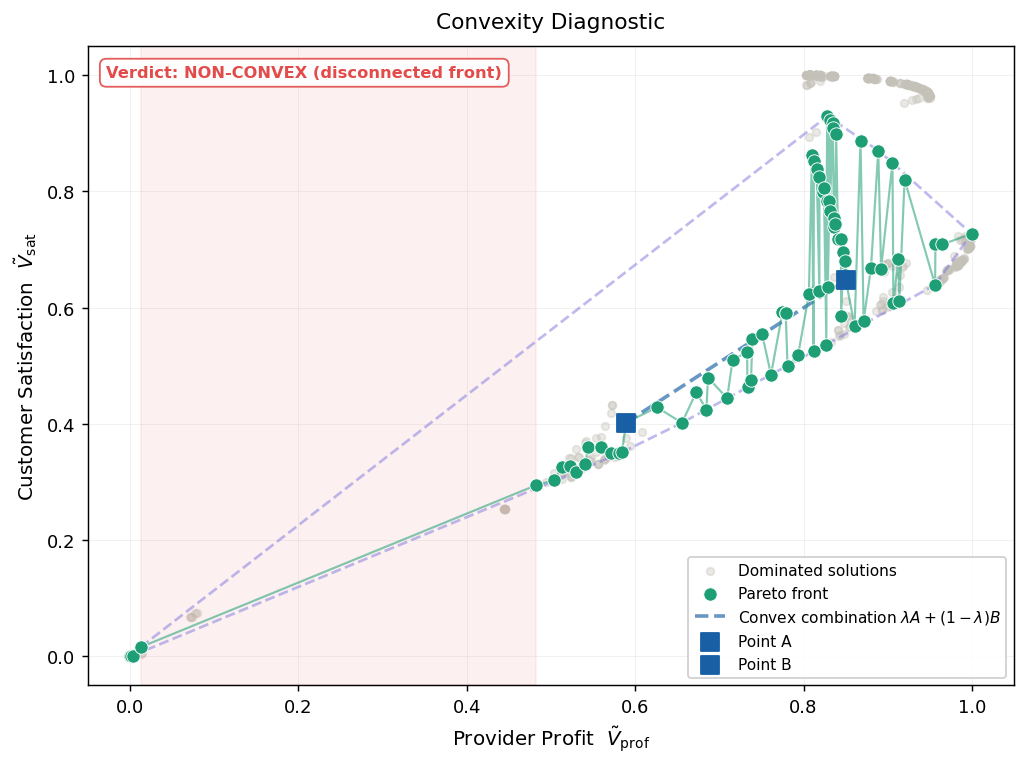

    Profit vs Satisfaction                 → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=1  all_on_hull=False


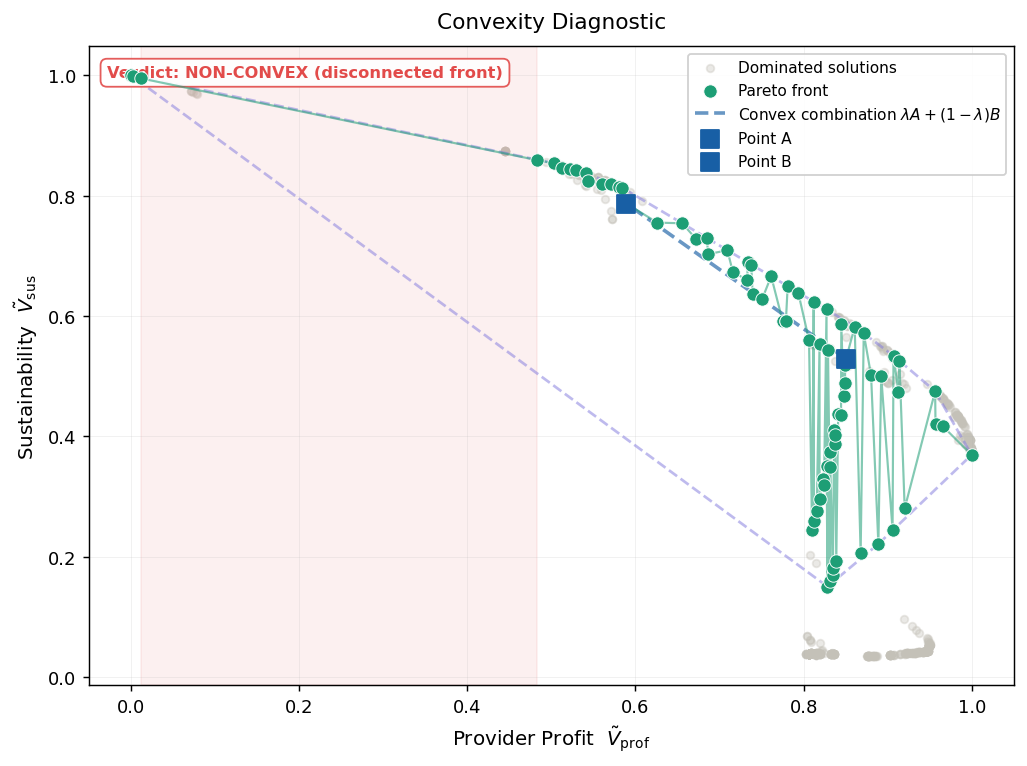

    Profit vs Sustainability               → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=1  all_on_hull=False


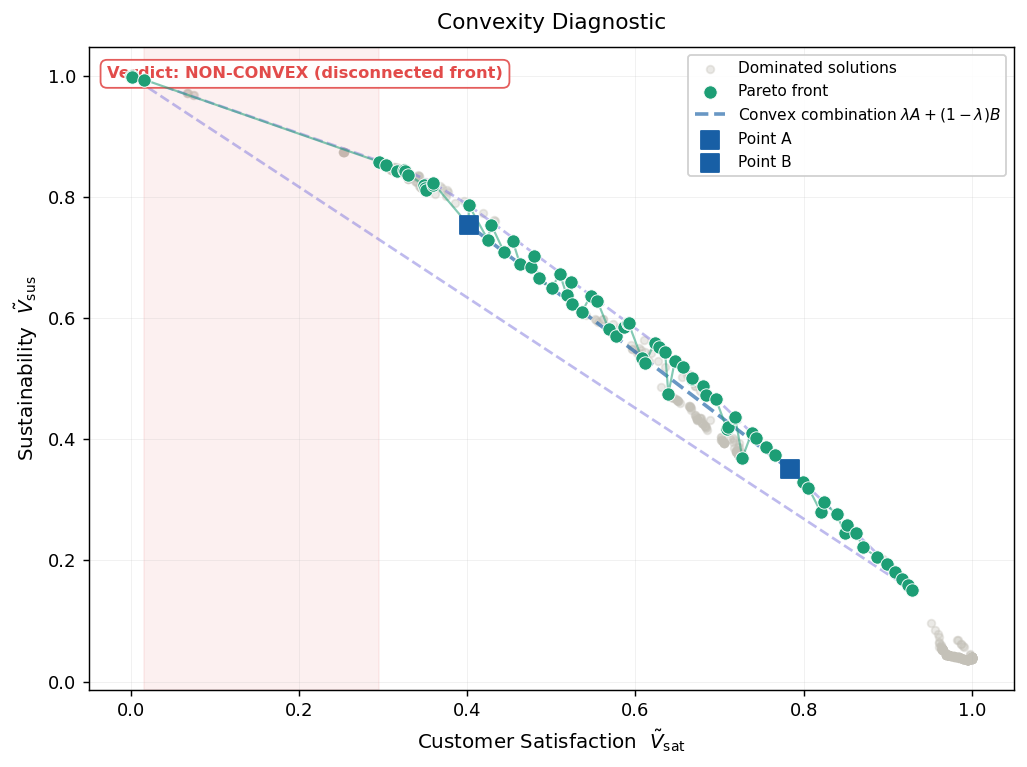

    Satisfaction vs Sustainability         → NON-CONVEX (disconnected front)
       Pareto pts=78  gaps=1  all_on_hull=False


In [58]:
pairs  = [('V_prof','V_sat'), ('V_prof','V_sus'), ('V_sat','V_sus')]
labels = ['Profit vs Satisfaction', 'Profit vs Sustainability', 'Satisfaction vs Sustainability']

print('=' * 80)
print('CONVEXITY DIAGNOSTIC RESULTS')
print('=' * 80)

for method, sols, mlabel in [
    ('linear',    solutions_linear,    'Linear Scalarization'),
    ('epsilon',   solutions_epsilon,   'epsilon-Constraint'),
    ('chebyshev', solutions_chebyshev, 'Chebyshev'),
]:
    print(f'\n  {mlabel}')
    for (ox, oy), plabel in zip(pairs, labels):
        fig, diag = viz.plot_convexity_diagnostic(
            sols,
            dominated_pool=dominated_pool,
            method_name=method,
            obj_x=ox, obj_y=oy,
            save_path=f'convexity_{method}_{ox}_{oy}.png',
        )
        plt.show()
        print(f'    {plabel:<38} → {diag["verdict"]}')
        print(f'       Pareto pts={diag["n_pareto_points"]}  gaps={diag["n_gaps"]}  '
              f'all_on_hull={diag["all_points_on_convex_hull"]}')

## Numerical Summary (Normalized Objectives)

In [17]:
viz.print_method_summary({
    'linear':    solutions_linear,
    'epsilon':   solutions_epsilon,
    'chebyshev': solutions_chebyshev,
})
print('Values are in normalized [0,1] space. 1.0 = Utopian, 0.0 = Nadir.')


Method                               # Pareto   Avg Ṽ_sat  Avg Ṽ_prof   Avg Ṽ_sus
Linear Scalarization (Weighted-Sum)       253      0.6908      0.8206      0.3995
ε-Constraint Method                       324      0.4316      0.6109      0.6464
Chebyshev (Minimax) Scalarization         253      0.5848      0.7324      0.5529

Values are in normalized [0,1] space. 1.0 = Utopian, 0.0 = Nadir.


## Optimal Upper Bound Analysis

$$\mathcal{X}_{\text{online}} \subseteq \mathcal{X}_{\text{offline}} \subseteq \mathcal{X}_{\text{Fluid LP}}$$

Both inclusions enlarge the feasible set → Fluid LP optimum $\geq$ any online optimum.

In [18]:
print('=' * 75)
print('FLUID LP UPPER BOUNDS (normalized, = 1.0 by construction for each single obj)')
print('=' * 75)
print(f'  Max V_sat  (z_sat_max  = {optimizer.z_sat_max:>12,.2f})  →  norm = 1.0000')
print(f'  Max V_prof (z_prof_max = {optimizer.z_prof_max:>12,.2f})  →  norm = 1.0000')
print(f'  Min Carbon (z_carb_max = {optimizer.z_carb_max:>12,.2f})  →  V_sus norm = 1.0000')

for method, sols, label in [
    ('linear',    solutions_linear,    'Linear'),
    ('epsilon',   solutions_epsilon,   'eps-Constraint'),
    ('chebyshev', solutions_chebyshev, 'Chebyshev'),
]:
    om  = _extract_objective_matrix(sols, ['V_sat','V_prof','V_sus'])
    pi  = _compute_pareto_indices_max(om)
    pts = om[pi]
    if len(pts) > 0:
        print(f'\n  {label} ({len(pi)} Pareto pts):')
        print(f'    Avg Ṽ_sat  = {pts[:,0].mean():.4f}  ({pts[:,0].mean()*100:.1f}% of upper bound)')
        print(f'    Avg Ṽ_prof = {pts[:,1].mean():.4f}  ({pts[:,1].mean()*100:.1f}% of upper bound)')
        print(f'    Avg Ṽ_sus  = {pts[:,2].mean():.4f}  ({pts[:,2].mean()*100:.1f}% of upper bound)')

FLUID LP UPPER BOUNDS (normalized, = 1.0 by construction for each single obj)
  Max V_sat  (z_sat_max  = 1,030,866,108.63)  →  norm = 1.0000
  Max V_prof (z_prof_max = 239,403,718.66)  →  norm = 1.0000
  Min Carbon (z_carb_max = 22,066,550.55)  →  V_sus norm = 1.0000

  Linear (253 Pareto pts):
    Avg Ṽ_sat  = 0.6908  (69.1% of upper bound)
    Avg Ṽ_prof = 0.8206  (82.1% of upper bound)
    Avg Ṽ_sus  = 0.3995  (39.9% of upper bound)

  eps-Constraint (324 Pareto pts):
    Avg Ṽ_sat  = 0.4316  (43.2% of upper bound)
    Avg Ṽ_prof = 0.6109  (61.1% of upper bound)
    Avg Ṽ_sus  = 0.6464  (64.6% of upper bound)

  Chebyshev (253 Pareto pts):
    Avg Ṽ_sat  = 0.5848  (58.5% of upper bound)
    Avg Ṽ_prof = 0.7324  (73.2% of upper bound)
    Avg Ṽ_sus  = 0.5529  (55.3% of upper bound)
